# 05 — Deep learning: red neuronal tabular

**TFM: Predicción de emisiones de CO₂ de buques (THETIS-MRV)**

*Objetivo: comprobar si una red neuronal densa mejora el **R² = 0,8266 en validación cruzada
agrupada por buque** que fija XGBoost en el notebook 04, con el 0,8301 del *stacking* como techo de
las técnicas clásicas.*

Técnicas: construcción de redes con Keras (API secuencial y funcional), prevención del sobreajuste
(dropout, L2, early stopping) y ajuste de hiperparámetros con Keras Tuner.

**Reglas heredadas del notebook 04, que no se tocan** para que la comparación sea honesta:

1. La decisión entre modelos se toma **en validación cruzada sobre train**, nunca en el test.
2. La validación cruzada es `GroupKFold(3)` **agrupada por buque**, la misma con la que se midió
   XGBoost.
3. Toda predicción se recorta a cero (restricción física: no existen emisiones negativas).
4. El test se toca **una sola vez**, al final, y no participa en ninguna decisión.

> **Tiempo de ejecución**: ~110 minutos en CPU (las secciones 9 y 10 suman unos 50 minutos). La parte cara son la búsqueda de
> hiperparámetros (sección 4, ~13 min) y las validaciones cruzadas de las secciones 6 y 6.1
> (~30 min entre las dos). Los resultados numéricos pueden variar en la última milésima al
> ejecutarse en otra máquina: TensorFlow no garantiza determinismo bit a bit entre plataformas ni
> entre distintos números de hilos, aunque la semilla sea la misma.

---

**Resultado del notebook, por delante:** la mejor red densa alcanza **R² 0,8189** en validación
cruzada agrupada por buque, frente a **0,8266** de XGBoost, con casi **100 veces** más coste de
entrenamiento — el deep learning **no** mejora al gradient boosting en este problema tabular. Lo que
sí aporta es diversidad: sus errores solo correlacionan 0,90 con los del árbol, y la media de ambas
predicciones llega a **0,8313** en validación cruzada y **0,8380** en test, por delante del
*stacking* de tres técnicas de árboles del notebook 04 (0,8301 / 0,8366).

Y dos resultados que matizan ese titular, en las secciones 9 y 10: **con la cuarta parte de los
buques la red gana** —así que su desventaja no viene de tener pocos datos, sino de tener muchos— y
**en el nivel de información operacional el empate es técnico**, con la mezcla de las dos familias
por encima de ambas (R² 0,9179 en CV y 0,9215 en test con las cifras de referencia).


> **Cifras del nivel operacional.** Las salidas impresas y las cifras citadas en las secciones 10 y
> 10.2 (0,8932 / 0,8937 / 0,9001) corresponden a una ejecución con cobertura de velocidad del 68,2%.
> Con la cobertura completa (94,0%, notebook 03, sección 4) y el mismo protocolo, las cifras de
> referencia son **XGBoost 0,9115 · red 0,9127 · mezcla 0,9179** en CV agrupada, y
> **0,9164 · 0,9156 · 0,9215** en test (`reports/05_nivel_operacional*.csv`). El detalle está en la
> nota de la sección 10.
>
> **El nivel de información principal —el grueso del notebook y el modelo de cabecera del TFM— no
> depende de la velocidad.**


> **Modelo que sirve el simulador.** Entre los niveles comparados en este cuaderno, la mejor opción
> es **la mezcla 50/50 del nivel operacional** (secciones 10, 11 y 12). Con la capacidad de carga
> reconstruida (notebook 03, sección 5) aparece el nivel **operacional+tamaño**, donde XGBoost solo
> alcanza **R² 0,9484** en test, por encima del 0,9215 de esa mezcla. Por eso **el simulador y la
> API sirven XGBoost sobre operacional+tamaño**. Nada de lo que este cuaderno *mide* cambia: el deep
> learning no mejora a XGBoost en el nivel principal.
>
> El tiempo de predicción de la SVM que se cita en la sección 11 es de **38,9 segundos** para las
> 21.105 filas de test (notebook 04).

In [1]:
import sys
import time
import tempfile
from pathlib import Path

import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

sys.path.insert(0, '../src')

from feature_engineering import RANDOM_STATE
from modelizacion_ml import calcular_metricas
import deep_learning as dl

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

print(f'TensorFlow {tf.__version__} | Keras {keras.__version__}')

df_principal_ml = pd.read_parquet('../data/processed/mrv_features_principal_ml.parquet')
df_principal_raw = pd.read_parquet('../data/processed/mrv_features_principal_raw.parquet')

for nombre, d in [('principal_ml', df_principal_ml), ('principal_raw', df_principal_raw)]:
    print(f'{nombre}: {d.shape[0]:,} filas x {d.shape[1]} columnas'.replace(',', '.'))

# Los índices de partición se calculan sobre `principal_ml` (sección 1) y se aplican con `.loc` al
# dataset `principal_raw` en las secciones 5 y 8. Eso solo es válido si las dos tablas están
# alineadas fila a fila. No se da por supuesto: se comprueba aquí, y el notebook se para si las
# filas no estuvieran en el mismo orden.
CLAVES_ALINEAMIENTO = ['reporting_year', 'ship_imo_number', 'total_co2_emissions_m_tonnes', 'es_train']
assert len(df_principal_ml) == len(df_principal_raw), 'principal_ml y principal_raw no tienen las mismas filas'
assert all((df_principal_ml[c].values == df_principal_raw[c].values).all() for c in CLAVES_ALINEAMIENTO), \
    'principal_ml y principal_raw han dejado de estar alineados fila a fila'
print('Alineamiento fila a fila entre principal_ml y principal_raw: verificado.')


I0000 00:00:1787227742.331757   28254 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787227742.376378   28254 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787227744.160892   28254 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0 | Keras 3.15.1


principal_ml: 106.521 filas x 41 columnas
principal_raw: 106.521 filas x 14 columnas


Alineamiento fila a fila entre principal_ml y principal_raw: verificado.


## 1. Qué cambia respecto del notebook 04

Los datos, los predictores y las particiones son exactamente los mismos que en el notebook 04.
Lo que cambia es la preparación que una red necesita y un árbol no:

1. **Hay que escalar.** Un árbol de decisión solo compara valores con umbrales, así que le da
   igual que `time_spent_at_sea_hours` esté en miles de horas y las variables dummy en {0, 1}.
   Una red suma entradas ponderadas: sin estandarizar, las variables de escala grande dominan el
   gradiente. Se estandarizan los predictores **y el objetivo** (el CO₂ está en decenas de miles
   de toneladas; con `mse` sobre esa escala la pérdida inicial es del orden de 10⁸ y el
   entrenamiento arranca inestable). Los estadísticos de escalado se calculan siempre **solo con
   las filas de entrenamiento**, nunca con las de validación o test.

2. **La validación interna del early stopping también tiene que ir agrupada por buque.**
   `model.fit(..., validation_split=0.15)` de Keras separa el último 15% de las filas *tal cual
   llegan*, sin agrupar: el mismo buque acabaría a la vez en entrenamiento y en la validación que
   decide cuándo parar. Es exactamente el mismo error silencioso que el `cv=3` sin agrupar
   (notebook 04, sección 3.1), y se resuelve igual: construyendo la partición
   a mano con `GroupShuffleSplit` por buque.

3. **Hace falta una partición de exploración.** Comparar variantes rápidas (escalado del
   objetivo, activación de salida, regularización) con validación cruzada completa costaría horas.
   Se reserva un 20% del train, agrupado por buque, como conjunto de exploración; las secciones 2
   a 5 comparan ahí, y la **decisión** de la sección 6 se toma con la validación cruzada completa.
   El test sigue sin tocarse.

   Conviene declarar el matiz: ese 20% de exploración **está dentro** del train sobre el que luego
   se hace la validación cruzada de la sección 6, así que la estimación de CV de la arquitectura
   ganadora es ligeramente optimista. El sesgo juega en contra de la conclusión de este notebook
   (que la red pierde frente a XGBoost), o sea que es conservador; y el test, que es de donde sale
   la estimación que se reporta, queda fuera de todo el proceso.

In [2]:
predictoras = dl.predictoras_ml(df_principal_ml)
train = df_principal_ml[df_principal_ml['es_train']].reset_index(drop=True)
test = df_principal_ml[~df_principal_ml['es_train']].reset_index(drop=True)

x_train = train[predictoras].astype('float32').values
y_train = train[dl.TARGET_COL].values.astype('float64')
grupos_train = train[dl.COL_GRUPO].values

x_test = test[predictoras].astype('float32').values
y_test = test[dl.TARGET_COL].values.astype('float64')

print(f'{len(predictoras)} predictoras | train {x_train.shape[0]:,} filas '
      f'({len(np.unique(grupos_train)):,} buques) | test {x_test.shape[0]:,} filas'.replace(',', '.'))

# Partición de exploración (20% del train, agrupada por buque) y, dentro del resto,
# la validación interna del early stopping (15%, también agrupada).
idx_ajuste_total, idx_exploracion = dl.particion_interna_agrupada(
    grupos_train, proporcion_val=0.20, semilla=RANDOM_STATE)
sub_ajuste, sub_validacion = dl.particion_interna_agrupada(
    grupos_train[idx_ajuste_total], proporcion_val=0.15, semilla=RANDOM_STATE)
idx_ajuste = idx_ajuste_total[sub_ajuste]
idx_validacion = idx_ajuste_total[sub_validacion]

from sklearn.preprocessing import StandardScaler

escalador_x = StandardScaler().fit(x_train[idx_ajuste])
escalador_y = dl.EscaladoObjetivo(y_train[idx_ajuste])

x_aj = escalador_x.transform(x_train[idx_ajuste]).astype('float32')
x_val = escalador_x.transform(x_train[idx_validacion]).astype('float32')
x_expl = escalador_x.transform(x_train[idx_exploracion]).astype('float32')
y_aj_esc = escalador_y.transformar(y_train[idx_ajuste])
y_val_esc = escalador_y.transformar(y_train[idx_validacion])
y_expl = y_train[idx_exploracion]

for nombre, idx in [('ajuste', idx_ajuste), ('validación interna', idx_validacion),
                    ('exploración', idx_exploracion)]:
    print(f'{nombre:20s} {len(idx):>7,} filas   {len(np.unique(grupos_train[idx])):>6,} buques'
          .replace(',', '.'))

print('\nBuques compartidos entre particiones (debe ser 0 en los tres casos):')
for a, b in [('ajuste', 'validación interna'), ('ajuste', 'exploración'),
             ('validación interna', 'exploración')]:
    ia = {'ajuste': idx_ajuste, 'validación interna': idx_validacion, 'exploración': idx_exploracion}
    print(f'  {a} ∩ {b}: {len(set(grupos_train[ia[a]]) & set(grupos_train[ia[b]]))}')

34 predictoras | train 85.416 filas (20.641 buques) | test 21.105 filas


ajuste                58.210 filas   14.035 buques
validación interna    10.118 filas    2.477 buques
exploración           17.088 filas    4.129 buques

Buques compartidos entre particiones (debe ser 0 en los tres casos):
  ajuste ∩ validación interna: 0
  ajuste ∩ exploración: 0
  validación interna ∩ exploración: 0


## 2. Primera red: una arquitectura densa de referencia

Se empieza con una arquitectura densa estándar de regresión tabular: cuatro capas ocultas de 64
neuronas con activación `relu`, salida lineal, optimizador Adam y pérdida `mse`. Es el punto de
partida natural, aplicado aquí sin cambios.

In [3]:
dl.fijar_semilla(RANDOM_STATE)
red_base = dl.construir_red_densa(x_aj.shape[1], unidades=(64, 64, 64, 64))
red_base.summary()

Model: "red_densa"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,785 (57.75 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 0 (0.00 B)

Épocas entrenadas: 44 (early stopping, 39s)
Exploración -> R² 0.8174 | RMSE 5.785 t | MAE 2.748 t


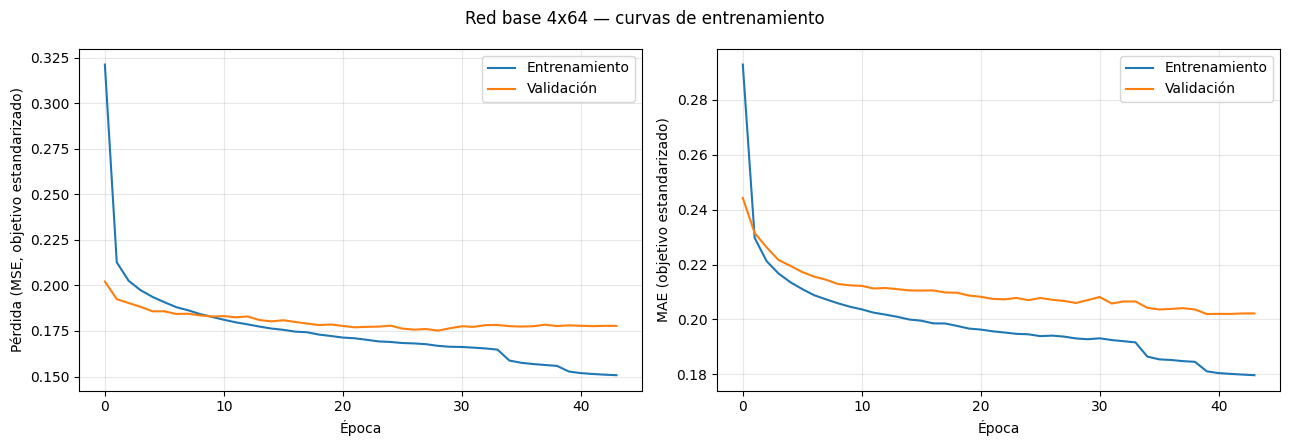

In [4]:
t0 = time.time()
red_base, historia_base = dl.entrenar_red(
    lambda: dl.construir_red_densa(x_aj.shape[1], unidades=(64, 64, 64, 64)),
    x_aj, y_aj_esc, x_val, y_val_esc)

pred_base = escalador_y.invertir(red_base.predict(x_expl, verbose=0))
metricas_base = calcular_metricas(y_expl, pred_base)
print(f'Épocas entrenadas: {len(historia_base.history["loss"])} '
      f'(early stopping, {time.time() - t0:.0f}s)')
print(f'Exploración -> R² {metricas_base["R2"]:.4f} | RMSE {metricas_base["RMSE"]:,.0f} t | '
      f'MAE {metricas_base["MAE"]:,.0f} t'.replace(',', '.'))

dl.graficar_historia(historia_base, 'Red base 4x64 — curvas de entrenamiento')

### 2.1. El objetivo hay que escalarlo — y el logaritmo no ayuda

La distribución del CO₂ es muy asimétrica (asimetría 3,09; ver notebook 02), y ante eso la receta
habitual es transformar el objetivo con `log1p`. Conviene medirlo en vez de suponerlo, porque
aquí la métrica de referencia (R²) se calcula en toneladas: un modelo entrenado en escala
logarítmica minimiza el error **relativo**, no el absoluto, y eso puede penalizarlo justo en los
buques grandes, que son los que más pesan en el R².

Se comparan tres tratamientos del objetivo con la misma arquitectura y la misma semilla.

In [5]:
def entrenar_con_objetivo(transformacion, unidades=(64, 64, 64, 64)):
    """Entrena la misma red con distintos tratamientos del objetivo y evalúa en toneladas."""
    if transformacion == 'crudo':
        f, inv = (lambda v: v), (lambda v: np.clip(np.ravel(v), 0, None))
    elif transformacion == 'estandarizado':
        f, inv = escalador_y.transformar, escalador_y.invertir
    elif transformacion == 'log1p':
        f, inv = (lambda v: np.log1p(v)), (lambda v: np.clip(np.expm1(np.ravel(v)), 0, None))
    else:
        raise ValueError(transformacion)

    t0 = time.time()
    modelo, historia = dl.entrenar_red(
        lambda: dl.construir_red_densa(x_aj.shape[1], unidades=unidades),
        x_aj, f(y_train[idx_ajuste]), x_val, f(y_train[idx_validacion]))
    pred = inv(modelo.predict(x_expl, verbose=0))
    return {'objetivo': transformacion, **calcular_metricas(y_expl, pred),
            'épocas': len(historia.history['loss']), 'segundos': round(time.time() - t0, 1)}


resultados_objetivo = pd.DataFrame([entrenar_con_objetivo(t)
                                    for t in ['crudo', 'estandarizado', 'log1p']])
resultados_objetivo.round(4)

,objetivo,RMSE,MAE,R2,épocas,segundos
0,crudo,5940.1957,2810.4581,0.8074,69,52.3
1,estandarizado,5784.8618,2747.5961,0.8174,44,38.4
2,log1p,6111.1599,2718.9252,0.7962,142,120.3


Escalar el objetivo aporta **+0,010 de R²** (0,8074 → 0,8174) y además llega antes: 44 épocas
frente a 69. La versión logarítmica es la peor de las tres (0,7962) pese a tener el mejor MAE
relativo entre las tres en algunos tramos, y necesita 142 épocas. El motivo es el que se anticipaba:
`log1p` convierte el problema en minimizar el error *relativo*, y el R² se calcula en toneladas, así
que penaliza justo donde más pesa la métrica — los buques grandes. Una transformación estándar del
objetivo no es gratis: cambia la función de pérdida que se está
optimizando de verdad.

### 2.2. La activación de la salida: `relu` parece razonable y es un error

Las emisiones no pueden ser negativas, así que poner `relu` en la neurona de salida parece una
forma elegante de imponer la restricción física — de hecho es una elección habitual para
problemas con objetivo positivo. Con este dataset no funciona, y conviene medirlo porque el motivo es instructivo: con el objetivo estandarizado, una parte de los buques
tiene valor negativo, la `relu` de salida los satura a cero y **el gradiente deja de circular**
para esas filas. La restricción física se aplica igual de bien después, al invertir el escalado
(`np.clip(..., 0, None)`), sin estropear el entrenamiento.

In [6]:
filas_activacion = []
for activacion in ['linear', 'relu']:
    dl.fijar_semilla(RANDOM_STATE)
    modelo = keras.Sequential([keras.Input(shape=(x_aj.shape[1],))])
    for _ in range(4):
        modelo.add(keras.layers.Dense(64, activation='relu'))
    modelo.add(keras.layers.Dense(1, activation=activacion))
    modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])
    modelo.fit(x_aj, y_aj_esc, validation_data=(x_val, y_val_esc), epochs=300, batch_size=256,
               callbacks=dl.callbacks_estandar(), verbose=0)
    pred = escalador_y.invertir(modelo.predict(x_expl, verbose=0))
    filas_activacion.append({'activación de salida': activacion, **calcular_metricas(y_expl, pred)})

pd.DataFrame(filas_activacion).round(4)

,activación de salida,RMSE,MAE,R2
0,linear,5784.8618,2747.5961,0.8174
1,relu,8134.0353,6430.6449,0.6389


La caída es enorme: **R² 0,639 frente a 0,817**, y el MAE se multiplica por 2,3 (de 2.748 a 6.431
toneladas). Con el objetivo estandarizado, los buques que emiten menos de la media tienen valor
negativo; la `relu` de salida los aplasta a cero y el gradiente que llega a esas filas es
exactamente cero, así que la red deja de aprender de ellas. La restricción física se sigue
cumpliendo en la versión con salida lineal — se aplica al invertir el escalado, igual que en las
técnicas del notebook 04 — pero sin estropear el entrenamiento.

Es un error silencioso en la misma línea que `gain` frente a `total_gain` o `cv=3` sin agrupar
(notebook 04): no lanza ninguna excepción, el código
parece correcto y hasta parece *más* correcto que la alternativa.

## 3. Regularización: dropout, L2 y early stopping

Las tres técnicas clásicas de prevención del sobreajuste, sobre una red más ancha (256-128-64) para que
la regularización tenga algo que regular. El early stopping con `restore_best_weights=True` ya
estaba activo en todos los entrenamientos anteriores; aquí se le suman `Dropout(0,1)` después de
cada capa oculta y penalización L2 de 5·10⁻⁴ sobre los pesos.

In [7]:
filas_regularizacion = []
for etiqueta, kwargs in [
    ('256-128-64 sin regularizar', dict(dropout=0.0, l2=0.0)),
    ('256-128-64 + dropout 0,1', dict(dropout=0.1, l2=0.0)),
    ('256-128-64 + dropout 0,1 + L2 5e-4', dict(dropout=0.1, l2=5e-4)),
]:
    t0 = time.time()
    modelo, historia = dl.entrenar_red(
        lambda: dl.construir_red_densa(x_aj.shape[1], unidades=(256, 128, 64), **kwargs),
        x_aj, y_aj_esc, x_val, y_val_esc)
    pred = escalador_y.invertir(modelo.predict(x_expl, verbose=0))
    filas_regularizacion.append({'red': etiqueta, **calcular_metricas(y_expl, pred),
                                 'épocas': len(historia.history['loss']),
                                 'segundos': round(time.time() - t0, 1)})
    if etiqueta.endswith('L2 5e-4'):
        historia_regularizada = historia

resultados_regularizacion = pd.DataFrame(filas_regularizacion)
resultados_regularizacion.round(4)

,red,RMSE,MAE,R2,épocas,segundos
0,256-128-64 sin regularizar,5757.3009,2598.6923,0.8191,101,99.0
1,"256-128-64 + dropout 0,1",5894.8366,2883.3984,0.8104,27,35.6
2,"256-128-64 + dropout 0,1 + L2 5e-4",5710.1777,2635.7860,0.8221,153,194.0


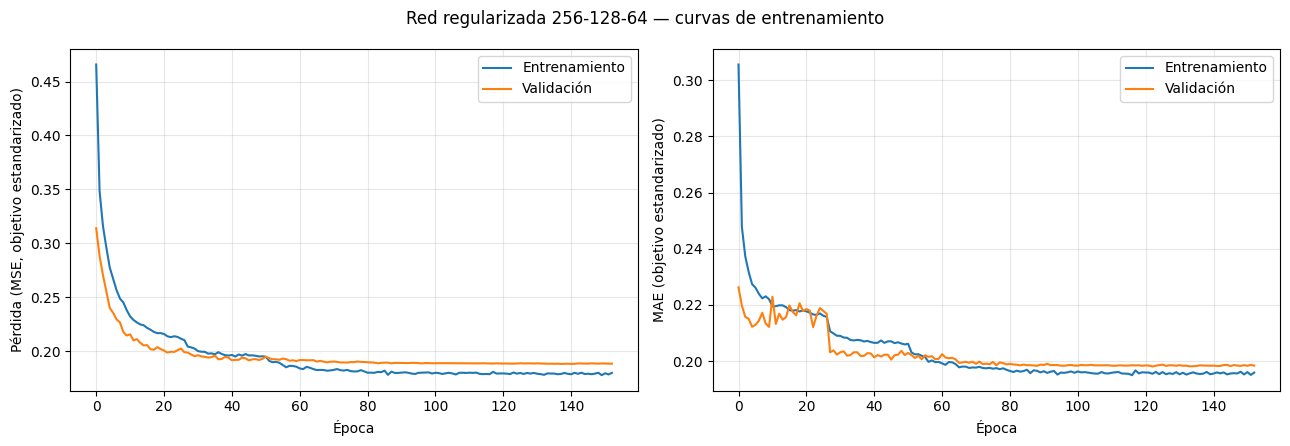

In [8]:
dl.graficar_historia(historia_regularizada, 'Red regularizada 256-128-64 — curvas de entrenamiento')

El dropout **por sí solo empeora** (0,8104 frente a 0,8191): con 34 entradas y una red de tres
capas no hay tanto que regularizar, y apagar neuronas al azar sobre todo hace que el early stopping
pare antes (27 épocas frente a 101). Combinado con la penalización L2 sí aporta, pero poco:
**0,8221**, unas tres milésimas por encima de la red sin regularizar, a cambio del doble de tiempo.

La conclusión honesta es que aquí el sobreajuste no es el problema. Las curvas lo confirman: la
pérdida de validación acompaña a la de entrenamiento en vez de separarse de ella. La red no se está
quedando corta por memorizar el train, sino por otra razón, que se ve en la sección 8: falla en
los mismos tipos de buque en los que falla XGBoost, y por el mismo motivo — lo que no está en
el dato público.

## 4. Ajuste de hiperparámetros con Keras Tuner

Hasta aquí la arquitectura se elige a mano. Keras Tuner automatiza esa búsqueda; se usa aquí con `RandomSearch` y 20 pruebas sobre un espacio de
número de capas, neuronas por capa, dropout por capa, penalización L2 y *learning rate*.

Dos adaptaciones, ambas por el mismo motivo (la agrupación por buque):

- en vez de `validation_split=0.15`, que parte sin agrupar, se pasa con `validation_data` la
  validación interna agrupada construida en la sección 1;
- el presupuesto por prueba se limita a 40 épocas con `patience=8`, para que la búsqueda quepa en
  unos 13 minutos. Es una limitación real y tiene consecuencias, como se ve en la sección 6.

In [9]:
import keras_tuner as kt


def construir_modelo_hp(hp):
    """Función de construcción para el tuner: cada llamada muestrea una configuración distinta."""
    modelo = keras.Sequential([keras.Input(shape=(x_aj.shape[1],))])
    l2 = hp.Choice('l2', [0.0, 1e-5, 1e-4, 1e-3])
    for i in range(hp.Int('num_layers', 2, 4)):
        modelo.add(keras.layers.Dense(
            hp.Int(f'units_{i}', 32, 256, step=32), activation='relu',
            kernel_regularizer=keras.regularizers.l2(l2) if l2 else None))
        modelo.add(keras.layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.3, step=0.1)))
    modelo.add(keras.layers.Dense(1, activation='linear'))
    modelo.compile(optimizer=keras.optimizers.Adam(hp.Choice('lr', [1e-2, 1e-3, 3e-4])),
                   loss='mse', metrics=['mae'])
    return modelo


dl.fijar_semilla(RANDOM_STATE)
directorio_tuner = tempfile.mkdtemp(prefix='kt_tfm05_')
tuner = kt.RandomSearch(construir_modelo_hp, objective='val_loss', max_trials=20, seed=0,
                        directory=directorio_tuner, project_name='tfm05', overwrite=True)

t0 = time.time()
tuner.search(x_aj, y_aj_esc, epochs=40, batch_size=256, validation_data=(x_val, y_val_esc),
             callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                                      restore_best_weights=True)],
             verbose=0)
print(f'Búsqueda completada en {time.time() - t0:.0f}s')

mejores_hp = tuner.get_best_hyperparameters(1)[0]
print('\nMejor configuración encontrada:')
for clave, valor in mejores_hp.values.items():
    print(f'  {clave}: {valor}')

Búsqueda completada en 767s

Mejor configuración encontrada:
  l2: 0.0
  num_layers: 2
  units_0: 160
  dropout_0: 0.0
  units_1: 64
  dropout_1: 0.0
  lr: 0.0003
  units_2: 64
  dropout_2: 0.1
  units_3: 160
  dropout_3: 0.0


In [10]:
# Tabla completa de pruebas, ordenada por la pérdida de validación (para la memoria / anexo).
filas_tuner = []
for _, prueba in tuner.oracle.trials.items():
    if prueba.score is not None:
        filas_tuner.append({**prueba.hyperparameters.values, 'val_loss': prueba.score})

tabla_tuner = pd.DataFrame(filas_tuner).sort_values('val_loss').reset_index(drop=True)
tabla_tuner.to_csv('../reports/05_tuner_pruebas.csv', index=False)
print(f'{len(tabla_tuner)} pruebas completadas. '
      f'val_loss entre {tabla_tuner.val_loss.min():.4f} y {tabla_tuner.val_loss.max():.4f}')
tabla_tuner.head(8).round(5)

20 pruebas completadas. val_loss entre 0.1743 y 0.2272


,l2,num_layers,units_0,dropout_0,units_1,dropout_1,lr,units_2,dropout_2,units_3,dropout_3,val_loss
0,0.00000,2,160,0.0,64,0.0,0.0003,64,0.1,160,0.0,0.17430
1,0.00000,3,192,0.1,96,0.0,0.0003,128,0.1,96,0.0,0.17476
2,0.00001,2,192,0.1,96,0.1,0.0010,192,0.0,192,0.2,0.17729
3,0.00001,2,192,0.0,224,0.2,0.0010,256,0.0,192,0.0,0.17904
4,0.00001,2,64,0.1,64,0.1,0.0003,32,0.2,256,0.2,0.18429
5,0.00010,3,160,0.2,32,0.1,0.0010,64,0.1,192,0.2,0.18923
6,0.00010,3,32,0.1,192,0.0,0.0010,224,0.0,224,0.0,0.19200
7,0.00001,4,256,0.1,224,0.2,0.0003,256,0.1,192,0.2,0.19318


### 4.1. Qué hiperparámetro importa de verdad

Se ajusta un Random Forest sobre los resultados de las pruebas para medir qué hiperparámetro
explica más la variación de la pérdida: una técnica del notebook 04 aplicada al propio proceso de
ajuste.

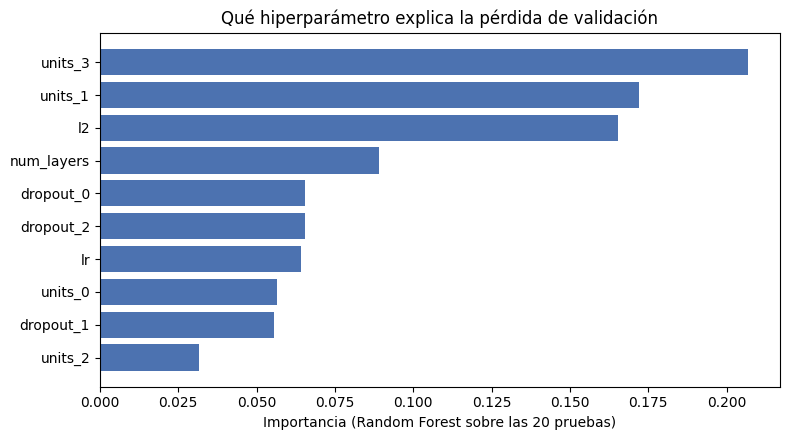

,hiperparámetro,importancia
0,units_3,0.2067
1,units_1,0.1720
2,l2,0.1653
3,num_layers,0.0891
4,dropout_0,0.0656
5,dropout_2,0.0653
6,lr,0.0641
7,units_0,0.0564


In [11]:
from sklearn.ensemble import RandomForestRegressor

x_hp = pd.get_dummies(tabla_tuner.drop(columns='val_loss'), dtype=float).fillna(-1)
bosque_hp = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE).fit(
    x_hp, tabla_tuner['val_loss'])

importancia_hp = (pd.DataFrame({'hiperparámetro': x_hp.columns,
                                'importancia': bosque_hp.feature_importances_})
                  .sort_values('importancia', ascending=False).reset_index(drop=True))

fig, eje = plt.subplots(figsize=(8, 4.5))
top = importancia_hp.head(10).iloc[::-1]
eje.barh(top['hiperparámetro'], top['importancia'], color='#4C72B0')
eje.set_xlabel('Importancia (Random Forest sobre las 20 pruebas)')
eje.set_title('Qué hiperparámetro explica la pérdida de validación')
plt.tight_layout()
plt.savefig('../reports/05_importancia_hiperparametros.png', dpi=120)
plt.show()

importancia_hp.head(8).round(4)

In [12]:
# La configuración ganadora del tuner, reentrenada a fondo (300 épocas, paciencia 15).
t0 = time.time()
dl.fijar_semilla(RANDOM_STATE)
red_tuner = tuner.hypermodel.build(mejores_hp)
historia_tuner = red_tuner.fit(x_aj, y_aj_esc, validation_data=(x_val, y_val_esc), epochs=300,
                               batch_size=256, callbacks=dl.callbacks_estandar(), verbose=0)
pred_tuner = escalador_y.invertir(red_tuner.predict(x_expl, verbose=0))
metricas_tuner = calcular_metricas(y_expl, pred_tuner)
print(f'Exploración -> R² {metricas_tuner["R2"]:.4f} | MAE {metricas_tuner["MAE"]:,.0f} t '
      f'({len(historia_tuner.history["loss"])} épocas, {time.time() - t0:.0f}s)'.replace(',', '.'))

Exploración -> R² 0.8116 | MAE 2.727 t (51 épocas. 44s)


Dos lecturas, y la segunda es la interesante.

**Sobre la importancia de hiperparámetros**: el ranking hay que leerlo con cuidado. `units_2` y
`units_3` solo existen en las configuraciones de 3 y 4 capas, y en las demás se han rellenado con
un valor centinela, así que su "importancia" actúa en parte como un sustituto de `num_layers`. Con
20 pruebas y 11 hiperparámetros, este análisis es orientativo — sirve para descartar dimensiones
irrelevantes, no para afinar.

**Sobre el resultado**: la configuración que el tuner declara ganadora (dos capas, 160 y 64
neuronas, sin regularización, *learning rate* 3·10⁻⁴) rinde **peor** en la partición de exploración
(R² 0,8116) que la red elegida a mano en la sección 3 (0,8221). No es un fallo del
tuner: es que ha optimizado `val_loss` sobre **una única partición de validación** y con un
presupuesto recortado de 40 épocas, y la diferencia entre las mejores configuraciones (0,1743 frente
a 0,1748 de pérdida) es más pequeña que el ruido de esa medición. La sección 6 lo confirma con
validación cruzada completa.

## 5. Variante con *embeddings*: la alternativa propia del deep learning tabular

Las cuatro variables categóricas del modelo entran como one-hot (una columna 0/1 por nivel), que
es lo que necesitan los modelos del notebook 04. El deep learning ofrece una alternativa que los
árboles no tienen: representar cada nivel por un **vector denso aprendido durante el
entrenamiento** (`Embedding`), de forma que la red pueda descubrir que, por ejemplo, un *bulk
carrier* y un *combination carrier* se parecen más entre sí que a un crucero.

Se implementa con la **API funcional** de Keras, porque el modelo tiene
varias entradas: una por cada categórica más el bloque de variables numéricas.

In [13]:
train_raw = df_principal_raw[df_principal_raw['es_train']].reset_index(drop=True)

codificado_aj, cardinalidades = dl.codificar_categoricas(
    train_raw.loc[idx_ajuste], train_raw.loc[idx_ajuste], dl.VAR_CAT_RAW)
print('Niveles por variable categórica (incluye el índice reservado a niveles no vistos):')
print(cardinalidades)

escalador_num = StandardScaler().fit(train_raw.loc[idx_ajuste, dl.VAR_NUM_RAW])


def entradas_embeddings(indices):
    codificado, _ = dl.codificar_categoricas(
        train_raw.loc[idx_ajuste], train_raw.loc[indices], dl.VAR_CAT_RAW)
    return {'numericas': escalador_num.transform(
        train_raw.loc[indices, dl.VAR_NUM_RAW]).astype('float32'), **codificado}


dl.fijar_semilla(RANDOM_STATE)
red_emb_demo = dl.construir_red_embeddings(cardinalidades, len(dl.VAR_NUM_RAW),
                                           unidades=(256, 128, 64), dropout=0.1)
red_emb_demo.summary()

Niveles por variable categórica (incluye el índice reservado a niveles no vistos):
{'ship_type_agrupado': 16, 'ice_class': 13, 'te_metodo': 6, 'prop_missings': 4}


Model: "red_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ship_type_agrupado  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ice_class           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ te_metodo           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prop_missings       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_ship_type_agru… │ (None, 1, 8)      │        128 │ ship_type_agrupa… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_ice_class       │ (None, 1, 7)      │         91 │ ice_class[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_te_metodo       │ (None, 1, 3)      │         18 │ te_metodo[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_prop_missings   │ (None, 1, 2)      │          8 │ prop_missings[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numericas           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ emb_ship_type_ag… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 7)         │          0 │ emb_ice_class[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 3)         │          0 │ emb_te_metodo[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ emb_prop_missing… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenado         │ (None, 23)        │          0 │ numericas[0][0],  │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │      6,144 │ concatenado[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 47,606 (185.96 KB)

 Trainable params: 47,606 (185.96 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
t0 = time.time()
red_emb, historia_emb = dl.entrenar_red(
    lambda: dl.construir_red_embeddings(cardinalidades, len(dl.VAR_NUM_RAW),
                                        unidades=(256, 128, 64), dropout=0.1),
    entradas_embeddings(idx_ajuste), y_aj_esc,
    entradas_embeddings(idx_validacion), y_val_esc)

pred_emb = escalador_y.invertir(red_emb.predict(entradas_embeddings(idx_exploracion), verbose=0))
metricas_emb = calcular_metricas(y_expl, pred_emb)
print(f'Exploración -> R² {metricas_emb["R2"]:.4f} | MAE {metricas_emb["MAE"]:,.0f} t '
      f'({len(historia_emb.history["loss"])} épocas, {time.time() - t0:.0f}s)'.replace(',', '.'))

Exploración -> R² 0.8222 | MAE 2.696 t (78 épocas. 114s)


La red con *embeddings* da el **mejor resultado de toda la exploración** (R² 0,8222). Conviene no
celebrarlo todavía: es una única partición, y la sección 6 mide las cuatro candidatas con la
validación cruzada completa, donde este orden cambia.

Nota sobre las dimensiones elegidas: con 15 tipos de buque y 12 clases de hielo, los *embeddings*
tienen poco margen para lucirse — su ventaja real aparece con categóricas de cientos o miles de
niveles (usuarios, productos, códigos postales). Aquí compiten casi en igualdad con el one-hot, que
es exactamente lo que cabe esperar, y por eso merece la pena medirlo en lugar de asumirlo en
cualquiera de los dos sentidos.

## 6. La decisión: validación cruzada agrupada contra XGBoost

Las secciones anteriores comparan sobre una única partición de exploración, que es rápida pero
ruidosa. La decisión se toma como en el notebook 04: `GroupKFold(3)` por buque sobre todo el train,
con la misma restricción de no negatividad y las mismas métricas.

XGBoost se reentrena aquí dentro del mismo bucle en lugar de reutilizar la cifra publicada del
notebook 04. Cuesta tres segundos y garantiza que las dos familias se miden exactamente con los
mismos folds y el mismo postproceso.

Y sirve además de comprobación cruzada entre notebooks, pero **hecha en código**: la celda lee el
R² del notebook 04 de `reports/04_comparativa_cv_agrupada.csv` —el fichero que lo generó— en lugar
de compararlo con una cifra escrita a mano en el texto, y falla con un `assert` si los dos notebooks
dejan de medir lo mismo. La comparativa del notebook 04 aplica el mismo recorte a cero que se usa
aquí, así que las dos cifras tienen que coincidir hasta el último dígito.

In [15]:
from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

filas_xgb, oof_xgb = [], np.full(len(y_train), np.nan)
for i, (idx_tr, idx_va) in enumerate(GroupKFold(n_splits=3).split(x_train, y_train,
                                                                  groups=grupos_train)):
    t0 = time.time()   # dentro del bucle: `segundos` es la duración de ESTE fold, no el acumulado
    modelo_xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                              tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
    modelo_xgb.fit(x_train[idx_tr], y_train[idx_tr])
    oof_xgb[idx_va] = np.clip(modelo_xgb.predict(x_train[idx_va]), 0, None)
    filas_xgb.append({'modelo': 'XGBoost (notebook 04)', 'fold': i,
                      **calcular_metricas(y_train[idx_va], oof_xgb[idx_va]),
                      'epocas': 200, 'segundos': round(time.time() - t0, 1)})

cv_xgb = pd.DataFrame(filas_xgb)

# Comprobación cruzada entre notebooks, leyendo la cifra del notebook 04 del fichero que la generó.
ref_nb04 = pd.read_csv('../reports/04_comparativa_cv_agrupada.csv').set_index('modelo')
r2_aqui = cv_xgb.R2.mean()
r2_nb04 = ref_nb04.loc['XGBoost', 'R2_cv_medio']
print(f'XGBoost en CV agrupada -> aquí {r2_aqui:.7f} | notebook 04 {r2_nb04:.7f} | '
      f'diferencia {abs(r2_aqui - r2_nb04):.2e}')
assert abs(r2_aqui - r2_nb04) < 1e-9, 'Los notebooks 04 y 05 han dejado de medir lo mismo'


XGBoost en CV agrupada -> aquí 0.8266076 | notebook 04 0.8266076 | diferencia 0.00e+00


In [16]:
# Las cuatro redes candidatas, con el mismo protocolo. ~17 minutos.
t0 = time.time()
cv_base, oof_base = dl.cv_agrupada_red(
    lambda n: dl.construir_red_densa(n, unidades=(64, 64, 64, 64)),
    x_train, y_train, grupos_train, nombre='Red densa 4x64 (estilo clase)',
    devolver_predicciones=True)

cv_reg, oof_reg = dl.cv_agrupada_red(
    lambda n: dl.construir_red_densa(n, unidades=(256, 128, 64), dropout=0.1, l2=5e-4),
    x_train, y_train, grupos_train, nombre='Red regularizada 256-128-64',
    devolver_predicciones=True)

unidades_tuner = tuple(mejores_hp.get(f'units_{i}') for i in range(mejores_hp.get('num_layers')))
dropout_tuner = tuple(mejores_hp.get(f'dropout_{i}') for i in range(mejores_hp.get('num_layers')))
cv_tuner, oof_tuner = dl.cv_agrupada_red(
    lambda n: dl.construir_red_densa(n, unidades=unidades_tuner, dropout=dropout_tuner,
                                     l2=mejores_hp.get('l2'), learning_rate=mejores_hp.get('lr')),
    x_train, y_train, grupos_train,
    nombre=f'Red del tuner {"-".join(map(str, unidades_tuner))}', devolver_predicciones=True)

cv_emb = dl.cv_agrupada_embeddings(
    train_raw,
    lambda card, n_num: dl.construir_red_embeddings(card, n_num, unidades=(256, 128, 64),
                                                    dropout=0.1),
    nombre='Red con embeddings 256-128-64')

print(f'Validación cruzada completa en {(time.time() - t0) / 60:.1f} minutos')

cv_todo = pd.concat([cv_xgb, cv_base, cv_reg, cv_tuner, cv_emb], ignore_index=True)
cv_todo.to_csv('../reports/05_cv_folds.csv', index=False)
resumen = dl.resumen_cv(cv_todo)
resumen.to_csv('../reports/05_comparativa_cv.csv', index=False)
resumen.round(4)

Validación cruzada completa en 18.2 minutos


,modelo,R2_CV,desv_R2,MAE_CV,RMSE_CV,epocas_medias,segundos_total
0,XGBoost (notebook 04),0.8266,0.0104,2592.8633,5701.8105,200.0000,3.7
1,Red densa 4x64 (estilo clase),0.8149,0.0145,2697.3812,5890.5898,77.0000,150.6
2,Red regularizada 256-128-64,0.8189,0.0133,2679.8471,5827.6942,106.3333,364.0
3,Red del tuner 160-64,0.8132,0.0128,2711.2490,5918.3128,158.0000,290.6
4,Red con embeddings 256-128-64,0.8157,0.0118,2721.5933,5878.6905,76.3333,277.7


Este es el resultado principal del notebook, y **el deep learning pierde**:

| Modelo | R² CV | Desv. típica | MAE CV (t) | Segundos |
|---|---:|---:|---:|---:|
| **XGBoost (notebook 04)** | **0,8266** | 0,0104 | 2.593 | **3,7** |
| Red regularizada 256-128-64 | 0,8189 | 0,0133 | 2.680 | 364 |
| Red con *embeddings* 256-128-64 | 0,8157 | 0,0118 | 2.722 | 278 |
| Red densa 4x64 (referencia) | 0,8149 | 0,0145 | 2.697 | 151 |
| Red del tuner 160-64 | 0,8132 | 0,0128 | 2.711 | 291 |

Tres observaciones:

1. **La mejor red se queda 0,008 de R² por debajo de XGBoost**, y le cuesta casi **100 veces más
   tiempo** de entrenamiento (364 s frente a 3,7 s en los mismos tres folds). No es una diferencia
   espectacular en calidad, pero va en la dirección contraria a la del coste.
2. **El orden de la exploración no se mantiene.** En la partición única, la red con *embeddings*
   ganaba (0,8222) y la regularizada iba segunda (0,8221); en validación cruzada la regularizada
   sube al primer puesto y los *embeddings* caen al tercero. Comparar sobre una sola partición es
   barato y sirve para descartar (la salida `relu`, el `log1p`), pero no para decidir.
3. **La configuración del tuner es la peor de las cuatro** (0,8132), por debajo incluso de la red
   básica de referencia. Automatizar la búsqueda no sustituye a validar bien: el tuner optimizó una
   señal ruidosa y eligió en consecuencia.

Y una lectura más, que no está en la tabla pero sí en los folds: **XGBoost gana a la red en los tres**
(0,8159 frente a 0,8042; 0,8273 frente a 0,8223; 0,8366 frente a 0,8301). No es una media que salga
a favor por un fold raro, es un resultado consistente.

Como comprobación cruzada entre notebooks, XGBoost reentrenado aquí reproduce el R² del notebook 04
hasta el último dígito (0,8266076), y la celda anterior lo comprueba con un `assert` contra el CSV
del notebook 04 en lugar de fiarlo a una cifra copiada en el texto.

### 6.1. ¿Son reales estas diferencias? Variabilidad por semilla

Antes de concluir nada hay que saber cuánto se mueve una red solo por el azar de la
inicialización de sus pesos. Si el ruido de semilla fuera del orden de las diferencias entre
arquitecturas, ninguna de las comparaciones anteriores significaría nada. Se repite la validación
cruzada completa de la mejor red con otras dos semillas.

In [17]:
t0 = time.time()
cv_semillas = [cv_reg.assign(modelo=f'Semilla {RANDOM_STATE}')]
for semilla in [7, 2026]:
    cv_semillas.append(dl.cv_agrupada_red(
        lambda n: dl.construir_red_densa(n, unidades=(256, 128, 64), dropout=0.1, l2=5e-4),
        x_train, y_train, grupos_train, semilla=semilla, nombre=f'Semilla {semilla}'))

cv_semillas = pd.concat(cv_semillas, ignore_index=True)
cv_semillas.to_csv('../reports/05_cv_semillas.csv', index=False)
print(f'{(time.time() - t0) / 60:.1f} minutos')
dl.resumen_cv(cv_semillas).round(5)

12.2 minutos


,modelo,R2_CV,desv_R2,MAE_CV,RMSE_CV,epocas_medias,segundos_total
0,Semilla 1234567,0.81889,0.01325,2679.84714,5827.69418,106.33333,364.0
1,Semilla 7,0.81877,0.00914,2697.68302,5830.06691,102.33333,348.2
2,Semilla 2026,0.81883,0.01091,2682.82813,5828.98134,113.33333,376.1


Un matiz sobre qué mide exactamente este experimento: el parámetro `semilla` de `cv_agrupada_red`
controla **dos cosas a la vez**, la inicialización de los pesos (`keras.utils.set_random_seed`) y el
`GroupShuffleSplit` de la validación interna del early stopping. Así que lo que se está midiendo es
el ruido **conjunto** de las dos, no el de la inicialización por separado. Para lo que hace falta
aquí —saber si las diferencias entre arquitecturas son reales— eso es justo lo que interesa.

El resultado es que ese ruido conjunto es **pequeño**: las tres medias son 0,81889, 0,81877 y
0,81883, un rango de 0,00012 de R². A nivel de fold individual se mueve algo más (el fold 0 da
0,8042, 0,8086 y 0,8068, un rango de 0,0044), pero en los dos casos queda por debajo de las
diferencias que se están interpretando:

- la diferencia entre la red y XGBoost (0,0077) es mayor que el ruido en las dos escalas, y además
  XGBoost gana en los tres folds, así que es real y no cuestión de suerte;
- la diferencia entre las cuatro arquitecturas (0,8132 a 0,8189) también está por encima del ruido,
  así que el orden de la sección 6 es informativo;
- y, en cambio, las diferencias que se veían en la partición de exploración entre la red
  regularizada y la de *embeddings* (0,8221 frente a 0,8222) sí eran ruido — y, visto lo anterior,
  ruido *de la partición*, no de la inicialización ni del early stopping.

Traducido: en este problema, la fuente principal de incertidumbre no es el azar interno de la red,
sino qué buques caen en cada lado de la partición. Que es exactamente la razón de decidir siempre
en `GroupKFold` y nunca en una partición única.

### 6.2. Combinar las dos familias: dónde sí aporta la red

Una red que pierde por poco frente a XGBoost puede seguir siendo útil si **se equivoca en sitios
distintos**. Como las predicciones fuera de fold de las dos familias ya están calculadas, medir
la media de ambas no cuesta ningún entrenamiento adicional.

Un aviso de método antes de mirar los números. Sobre un vector de predicciones fuera de fold se
pueden calcular **dos R² distintos**: uno *pooled*, juntando las 85.416 predicciones en un solo
cálculo, y otro como **media de los tres R² de cada fold**. No dan lo mismo (para XGBoost, 0,8264
frente a 0,8266), y el 0,8266 de la sección 6 y el 0,8301 del *stacking* del notebook 04 son de la
segunda clase. Así que la tabla reporta las dos, y la comparación con el notebook 04 se hace con
su misma métrica.

In [18]:
from sklearn.metrics import r2_score

oof_mezcla = (oof_xgb + oof_reg) / 2

# Los mismos folds de la sección 6, para poder medir la mezcla con la métrica con la que se
# publicaron el 0,8266 de XGBoost y el 0,8301 del stacking del notebook 04 (media de R² por fold),
# además del R² pooled sobre todo el vector fuera de fold.
folds_cv = list(GroupKFold(n_splits=3).split(x_train, y_train, groups=grupos_train))


def r2_media_de_folds(pred):
    return float(np.mean([r2_score(y_train[idx_va], pred[idx_va]) for _, idx_va in folds_cv]))


filas_mezcla = []
for nombre, pred in [('XGBoost', oof_xgb), ('Red regularizada', oof_reg),
                     ('Media 50/50 de ambas', oof_mezcla)]:
    filas_mezcla.append({'modelo': nombre, **calcular_metricas(y_train, pred),
                         'R2_media_de_folds': r2_media_de_folds(pred)})

comparativa_mezcla = pd.DataFrame(filas_mezcla).rename(columns={'R2': 'R2_pooled'})
comparativa_mezcla.to_csv('../reports/05_combinacion_oof.csv', index=False)

# Las predicciones fuera de fold se guardan en disco: esta sección, sus figuras y cualquier
# reponderación posterior se pueden rehacer sin volver a entrenar nada (media hora de CPU).
pd.DataFrame({'ship_imo_number': grupos_train, 'co2_real': y_train,
              'oof_xgboost': oof_xgb, 'oof_red': oof_reg}).to_csv(
    '../reports/05_oof_predicciones.csv', index=False)

residuo_xgb = y_train - oof_xgb
residuo_red = y_train - oof_reg
correlacion = np.corrcoef(residuo_xgb, residuo_red)[0, 1]
print(f'Correlación entre los errores de las dos familias: {correlacion:.3f}')
comparativa_mezcla.round(4)


Correlación entre los errores de las dos familias: 0.904


,modelo,RMSE,MAE,R2_pooled,R2_media_de_folds
0,XGBoost,5707.7989,2592.8633,0.8264,0.8266
1,Red regularizada,5835.8209,2679.8471,0.8186,0.8189
2,Media 50/50 de ambas,5631.3218,2581.0600,0.8310,0.8313


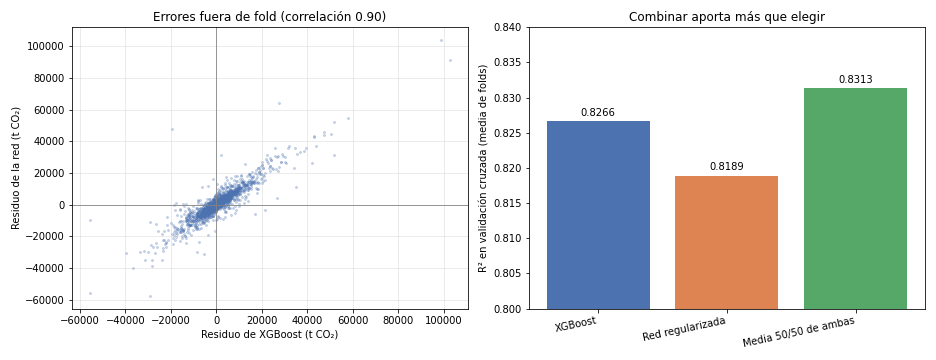

In [19]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

muestra = np.random.default_rng(RANDOM_STATE).choice(len(y_train), size=6000, replace=False)
ejes[0].scatter(residuo_xgb[muestra], residuo_red[muestra], s=4, alpha=0.25, color='#4C72B0')
ejes[0].axhline(0, color='grey', lw=0.8); ejes[0].axvline(0, color='grey', lw=0.8)
ejes[0].set_xlabel('Residuo de XGBoost (t CO₂)')
ejes[0].set_ylabel('Residuo de la red (t CO₂)')
ejes[0].set_title(f'Errores fuera de fold (correlación {correlacion:.2f})')
ejes[0].grid(alpha=0.3)

etiquetas = comparativa_mezcla['modelo']
ejes[1].bar(etiquetas, comparativa_mezcla['R2_media_de_folds'],
            color=['#4C72B0', '#DD8452', '#55A868'])
ejes[1].set_ylim(0.80, 0.84)
ejes[1].set_ylabel('R² en validación cruzada (media de folds)')
ejes[1].set_title('Combinar aporta más que elegir')
for i, valor in enumerate(comparativa_mezcla['R2_media_de_folds']):
    ejes[1].text(i, valor + 0.0008, f'{valor:.4f}', ha='center')
plt.setp(ejes[1].get_xticklabels(), rotation=12, ha='right')
plt.tight_layout()
plt.savefig('../reports/05_combinacion.png', dpi=120)
plt.show()

Aquí está el resultado que da sentido a la red. Los errores de las dos familias están correlacionados
(0,90), como era de esperar en el mismo problema, pero **no del todo**: hay un 10% de estructura del
error que cada familia captura por su cuenta. Basta para que la simple media aritmética de las dos
predicciones supere a cualquiera de ellas por separado:

| Modelo | R² media de folds | R² *pooled* |
|---|---:|---:|
| Red regularizada | 0,8189 | 0,8186 |
| XGBoost | 0,8266 | 0,8264 |
| **Media 50/50 de ambas** | **0,8313** | **0,8310** |

La media gana **+0,0047 de R²** sobre XGBoost solo, y lo hace **en los tres folds** (0,8185 frente a
0,8159; 0,8337 frente a 0,8273; 0,8418 frente a 0,8366). Para calibrar cuánto es eso: el *stacking*
de las tres técnicas de árboles del notebook 04 (Random Forest + Gradient Boosting + XGBoost, con
meta-modelo `RidgeCV`) llegaba a 0,8301 en la misma validación cruzada y con la misma métrica, con
cuatro modelos que entrenar. Aquí, dos modelos y una media sin ningún parámetro que ajustar llegan
más lejos — porque combinar familias *distintas* aporta más que combinar tres variantes del mismo
árbol.

Es la respuesta a por qué una red que pierde individualmente merece estar en el TFM.

### 6.3. ¿Y por qué 50/50?

Repartir a partes iguales es la opción sin parámetros, que es justo su gracia: no hay nada que
ajustar y por tanto nada que pueda sobreajustarse. Pero conviene comprobar que no se está dejando
mucho por el camino, y con las predicciones fuera de fold ya calculadas la comprobación no cuesta
ningún entrenamiento.

In [20]:
# Rejilla de pesos sobre las predicciones fuera de fold, en la misma métrica que la sección 6.
rejilla_pesos = pd.DataFrame([
    {'peso_xgboost': round(w, 2),
     'R2_media_de_folds': r2_media_de_folds(w * oof_xgb + (1 - w) * oof_reg)}
    for w in np.arange(0.0, 1.01, 0.05)])
rejilla_pesos.to_csv('../reports/05_rejilla_pesos.csv', index=False)

mejor_peso = rejilla_pesos.loc[rejilla_pesos.R2_media_de_folds.idxmax()]
r2_en_50 = rejilla_pesos.loc[rejilla_pesos.peso_xgboost == 0.50, 'R2_media_de_folds'].iloc[0]
print(f'Peso óptimo: {mejor_peso.peso_xgboost:.2f} -> R² {mejor_peso.R2_media_de_folds:.4f}')
print(f'Peso 50/50 : 0.50 -> R² {r2_en_50:.4f}  '
      f'(diferencia {mejor_peso.R2_media_de_folds - r2_en_50:.4f})')

rejilla_pesos[rejilla_pesos.peso_xgboost.between(0.29, 0.81)].round(4)


Peso óptimo: 0.60 -> R² 0.8317
Peso 50/50 : 0.50 -> R² 0.8313  (diferencia 0.0004)


,peso_xgboost,R2_media_de_folds
6,0.30,0.8284
7,0.35,0.8294
8,0.40,0.8302
9,0.45,0.8308
10,0.50,0.8313
11,0.55,0.8316
12,0.60,0.8317
13,0.65,0.8317
14,0.70,0.8315
15,0.75,0.8311


El óptimo está en 0,60 a favor de XGBoost y aporta **0,0004 de R²** sobre el 50/50 — cuatro
diezmilésimas, y la curva es plana entre 0,55 y 0,70. Es una ganancia del orden del ruido de
partición medido en la sección 6.1, así que **no compensa introducir un peso ajustado**: se queda la
media simple, que no tiene ningún parámetro que justificar ante el conjunto de test ni que
mantener en la API.

## 7. Estimación final sobre el test — una sola vez

Con la decisión ya tomada en validación cruzada, se entrena la red elegida sobre el train y se
evalúa en el test, que no ha intervenido en ninguna decisión de este notebook. Se reporta junto a
XGBoost y a la combinación de ambos.

Una asimetría que conviene declarar: la red se entrena con el **85%** del train, porque el 15%
restante se reserva para la validación interna que decide el early stopping, mientras que XGBoost
usa el **100%**. Es inevitable con early stopping y juega en contra de la red (y por tanto también
de la mezcla), así que las cifras de abajo son, si acaso, una cota inferior de lo que da la red.

In [21]:
escalador_x_final = StandardScaler().fit(x_train)
escalador_y_final = dl.EscaladoObjetivo(y_train)
aj_final, val_final = dl.particion_interna_agrupada(grupos_train, semilla=RANDOM_STATE)

t0 = time.time()
red_final, historia_final = dl.entrenar_red(
    lambda: dl.construir_red_densa(x_train.shape[1], unidades=(256, 128, 64), dropout=0.1, l2=5e-4),
    escalador_x_final.transform(x_train[aj_final]).astype('float32'),
    escalador_y_final.transformar(y_train[aj_final]),
    escalador_x_final.transform(x_train[val_final]).astype('float32'),
    escalador_y_final.transformar(y_train[val_final]))
print(f'{len(historia_final.history["loss"])} épocas, {time.time() - t0:.0f}s')

pred_test_red = escalador_y_final.invertir(
    red_final.predict(escalador_x_final.transform(x_test).astype('float32'), verbose=0))

xgb_final = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                         tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
xgb_final.fit(x_train, y_train)
pred_test_xgb = np.clip(xgb_final.predict(x_test), 0, None)
pred_test_mezcla = (pred_test_red + pred_test_xgb) / 2

comparativa_test = pd.DataFrame([
    {'modelo': 'Red neuronal 256-128-64', **calcular_metricas(y_test, pred_test_red)},
    {'modelo': 'XGBoost (notebook 04)', **calcular_metricas(y_test, pred_test_xgb)},
    {'modelo': 'Media 50/50 de ambas', **calcular_metricas(y_test, pred_test_mezcla)},
])
comparativa_test.to_csv('../reports/05_comparativa_test.csv', index=False)
comparativa_test.round(4)

106 épocas, 190s


,modelo,RMSE,MAE,R2
0,Red neuronal 256-128-64,5910.5112,2774.4369,0.8250
1,XGBoost (notebook 04),5761.7483,2685.8720,0.8337
2,Media 50/50 de ambas,5686.7702,2677.9444,0.8380


Estimación final sobre el test, reportada una sola vez y sin haber intervenido en ninguna decisión:

| Modelo | R² test | RMSE (t) | MAE (t) |
|---|---:|---:|---:|
| Red neuronal 256-128-64 | 0,8250 | 5.910,5 | 2.774,4 |
| XGBoost (notebook 04) | 0,8337 | 5.761,7 | 2.685,9 |
| **Media 50/50 de ambas** | **0,8380** | **5.686,8** | **2.677,9** |

El test confirma lo que dijo la validación cruzada, con la misma ordenación y diferencias del mismo
tamaño — señal de que el protocolo no ha dejado ninguna fuga. XGBoost reproduce clavado el 0,8337
del notebook 04.

La combinación es el **mejor resultado del proyecto** para el nivel de información principal, por
delante del 0,8366 del *stacking* del notebook 04. Aun así, el modelo de trabajo del TFM sigue
siendo XGBoost por lo mismo que se argumenta allí: la interpretabilidad con SHAP (notebook 07)
necesita un modelo que se pueda explicar, y explicar una media de un
árbol y una red es notablemente más incómodo que explicar el árbol. La combinación se reporta como
lo que es —una cota superior y una línea de trabajo futuro para la API— y la red queda guardada
como segundo modelo disponible.

In [22]:
red_final.save('../models/modelo_dl.keras')

# El fichero .keras por sí solo NO permite predecir: la red recibe predictores estandarizados y
# devuelve un objetivo estandarizado, así que sin los escaladores no hay forma de volver a
# toneladas de CO₂. Se guarda junto al modelo todo lo que hace falta para usarlo —escalador de X,
# media y desviación del objetivo, orden exacto de las columnas y el postproceso— que es
# exactamente lo que consume la API.
joblib.dump({'escalador_x': escalador_x_final,
             'media_y': escalador_y_final.media,
             'desv_y': escalador_y_final.desv,
             'predictoras': predictoras,
             'postproceso': 'clip_negativos_a_cero'},
            '../models/preproceso_dl.joblib')

# Y las predicciones sobre test de las tres opciones, para no tener que reentrenar nada en la
# interpretabilidad (notebook 07) ni en la API.
pd.DataFrame({'ship_imo_number': test[dl.COL_GRUPO].values, 'co2_real': y_test,
              'pred_red': pred_test_red, 'pred_xgboost': pred_test_xgb,
              'pred_media': pred_test_mezcla}).to_csv('../reports/05_test_predicciones.csv', index=False)

print(f'Modelo guardado: {Path("../models/modelo_dl.keras").stat().st_size / 1024:.0f} KB '
      f'({red_final.count_params():,} parámetros)'.replace(',', '.'))
print(f'Preproceso guardado: {Path("../models/preproceso_dl.joblib").stat().st_size / 1024:.0f} KB')


Modelo guardado: 625 KB (50.177 parámetros)
Preproceso guardado: 2 KB


In [23]:
# Comprobación de que el par (modelo, preproceso) es autosuficiente: se recarga desde disco y se
# reconstruye la predicción del test partiendo del dataframe original, sin usar ninguna variable
# que siga en memoria. Si esto funciona, la API puede servir el modelo sin este notebook.
preproceso = joblib.load('../models/preproceso_dl.joblib')
red_recargada = keras.models.load_model('../models/modelo_dl.keras')

x_check = preproceso['escalador_x'].transform(
    test[preproceso['predictoras']].astype('float32').values).astype('float32')
pred_check = np.clip(red_recargada.predict(x_check, verbose=0).ravel() * preproceso['desv_y']
                     + preproceso['media_y'], 0, None)

diferencia = np.abs(pred_check - pred_test_red).max()
print(f'Máxima diferencia con la predicción original: {diferencia:.4f} t CO₂ '
      f'(sobre predicciones de miles de toneladas: redondeo de float32)')
assert diferencia < 1.0, 'El modelo recargado no reproduce las predicciones'


Máxima diferencia con la predicción original: 0.0049 t CO₂ (sobre predicciones de miles de toneladas: redondeo de float32)


## 8. Diagnóstico: dónde gana cada familia

El R² global esconde el dato útil para los análisis siguientes. Se repite el análisis por tipo de
buque de la sección 4.4 del notebook 04, ahora comparando las dos familias sobre el test.

In [24]:
test_raw = df_principal_raw[~df_principal_raw['es_train']].reset_index(drop=True)
diagnostico = pd.DataFrame({'tipo': test_raw['ship_type_agrupado'], 'real': y_test,
                            'red': pred_test_red, 'xgb': pred_test_xgb})

por_tipo = (diagnostico.groupby('tipo')
            .apply(lambda d: pd.Series({
                'n': len(d),
                'R2_red': r2_score(d['real'], d['red']),
                'R2_xgb': r2_score(d['real'], d['xgb']),
                'MAE_red': np.abs(d['real'] - d['red']).mean(),
                'MAE_xgb': np.abs(d['real'] - d['xgb']).mean()}), include_groups=False)
            .sort_values('n', ascending=False))
por_tipo['gana'] = np.where(por_tipo['R2_red'] > por_tipo['R2_xgb'], 'red', 'XGBoost')
por_tipo.to_csv('../reports/05_error_por_tipo_buque.csv')
por_tipo.round(3)

,n,R2_red,R2_xgb,MAE_red,MAE_xgb,gana
tipo,,,,,,
Bulk carrier,6337.0,0.828,0.799,773.377,795.108,red
Oil tanker,3257.0,0.828,0.832,1738.608,1694.005,XGBoost
Container ship,3183.0,0.779,0.788,6055.903,5825.131,XGBoost
General cargo ship,2287.0,0.478,0.516,1508.764,1388.897,XGBoost
Chemical tanker,2053.0,0.800,0.813,1139.300,1095.590,XGBoost
Vehicle carrier,760.0,0.828,0.850,1731.961,1585.599,XGBoost
Ro-pax ship,712.0,0.577,0.582,12638.848,12766.186,XGBoost
Gas carrier,562.0,0.528,0.483,2700.046,2832.415,red
LNG carrier,507.0,0.719,0.804,6556.200,5643.775,XGBoost


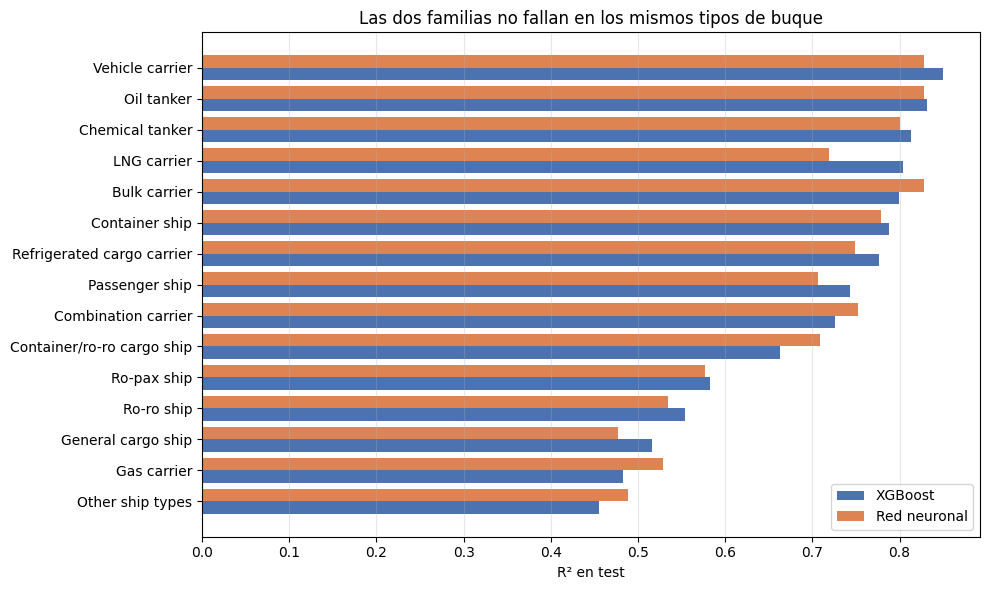

In [25]:
fig, eje = plt.subplots(figsize=(10, 6))
orden = por_tipo.sort_values('R2_xgb')
posiciones = np.arange(len(orden))
eje.barh(posiciones - 0.2, orden['R2_xgb'], height=0.4, label='XGBoost', color='#4C72B0')
eje.barh(posiciones + 0.2, orden['R2_red'], height=0.4, label='Red neuronal', color='#DD8452')
eje.set_yticks(posiciones); eje.set_yticklabels(orden.index)
eje.set_xlabel('R² en test'); eje.legend(loc='lower right')
eje.set_title('Las dos familias no fallan en los mismos tipos de buque')
eje.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/05_r2_por_tipo_familias.png', dpi=120)
plt.show()

El detalle por tipo de buque explica **por qué** funciona la media, y es más informativo que
cualquiera de los dos R² globales. Las dos familias no fallan en los mismos sitios:

- **La red gana en 5 de los 15 tipos**: bulk carrier (0,828 frente a 0,799 — y es el tipo más
  numeroso del test, con 6.337 filas), gas carrier (0,528 frente a 0,483), *other ship types*
  (0,489 frente a 0,456), container/ro-ro (0,708 frente a 0,663) y combination carrier.
- **XGBoost gana claramente en LNG carrier** (0,804 frente a 0,719) y en general en los tipos con
  pocas filas y consumo muy particular (pasaje, ro-ro, refrigerados).

El patrón tiene sentido: la red, al compartir todos sus pesos entre todos los tipos, generaliza
mejor allí donde hay muchísimos datos homogéneos y donde la relación es suave; el árbol aísla
mejor los segmentos pequeños y con comportamiento propio, porque puede dedicarles ramas enteras.

Los dos peores tipos siguen siendo los mismos que en el notebook 04 —carga general (R² ~0,5) y
ro-pax (~0,58)— y ninguna de las dos familias los arregla. Eso refuerza el diagnóstico: es un
**límite del dato**, no del algoritmo. El MRV público no publica ni el tamaño real del buque ni la
carga transportada ni el consumo hotelero, que es justo lo que explicaría a esos dos.

## 9. ¿Le faltan datos a la red?

Ante un "el deep learning pierde", la primera objeción razonable es siempre la misma: *¿o es que
tienes pocos datos?* Es una crítica justa —las redes profundas son conocidas por necesitar volumen—
y responderla citando la literatura no vale, porque la respuesta depende del problema. Aquí se puede
medir: basta entrenar las dos familias con **el 25%, 50%, 75% y 100% de los buques** de train de
cada fold y evaluar siempre sobre el fold retenido completo.

El submuestreo es **por buque, no por fila**, por la misma razón que todo lo demás en este proyecto:
quitar filas sueltas dejaría los años restantes del mismo buque dentro del entrenamiento y la curva
mediría otra cosa.

> Coste: ~25 minutos. Las tres fracciones nuevas suman nueve entrenamientos de la red; el 100% ya
> estaba medido en la sección 6 y se vuelve a calcular aquí para que la curva sea homogénea.

In [26]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error


def submuestra_agrupada(indices, fraccion):
    """Submuestra de buques enteros del train de un fold — la misma que aplica `cv_agrupada_red`."""
    if fraccion >= 1.0:
        return indices
    conservados, _ = next(GroupShuffleSplit(n_splits=1, train_size=fraccion,
                                            random_state=RANDOM_STATE)
                          .split(np.zeros(len(indices)), np.zeros(len(indices)),
                                 groups=grupos_train[indices]))
    return indices[conservados]


filas_curva = []
for fraccion in [0.25, 0.50, 0.75, 1.00]:
    cv_frac = dl.cv_agrupada_red(
        lambda n: dl.construir_red_densa(n, unidades=(256, 128, 64), dropout=0.1, l2=5e-4),
        x_train, y_train, grupos_train, fraccion_train=fraccion,
        nombre=f'Red {fraccion:.0%}')

    for i, (idx_tr, idx_va) in enumerate(folds_cv):
        sub = submuestra_agrupada(idx_tr, fraccion)
        modelo = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                              tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
        modelo.fit(x_train[sub], y_train[sub])
        pred_xgb_frac = np.clip(modelo.predict(x_train[idx_va]), 0, None)

        filas_curva.append({'fraccion': fraccion, 'fold': i,
                            'n_buques': int(len(np.unique(grupos_train[sub]))),
                            'n_filas': int(len(sub)),
                            'R2_xgb': r2_score(y_train[idx_va], pred_xgb_frac),
                            'R2_red': float(cv_frac.R2.iloc[i]),
                            'epocas': int(cv_frac.epocas.iloc[i])})

curva = pd.DataFrame(filas_curva)
curva.to_csv('../reports/05_curva_aprendizaje_folds.csv', index=False)

resumen_curva = (curva.groupby('fraccion')
                 .agg(buques=('n_buques', 'mean'), filas=('n_filas', 'mean'),
                      R2_xgb=('R2_xgb', 'mean'), R2_red=('R2_red', 'mean'),
                      epocas=('epocas', 'mean'))
                 .reset_index())
resumen_curva['ventaja_xgb'] = resumen_curva.R2_xgb - resumen_curva.R2_red
resumen_curva['folds_gana_red'] = (curva.assign(g=curva.R2_red > curva.R2_xgb)
                                   .groupby('fraccion').g.sum().values)
resumen_curva[['buques', 'filas']] = resumen_curva[['buques', 'filas']].round(0).astype(int)
resumen_curva.to_csv('../reports/05_curva_aprendizaje.csv', index=False)
resumen_curva.round(4)


,fraccion,buques,filas,R2_xgb,R2_red,epocas,ventaja_xgb,folds_gana_red
0,0.25,3440,14237,0.7777,0.7866,78.3333,-0.0089,3
1,0.50,6880,28321,0.8071,0.8055,78.0000,0.0015,2
2,0.75,10320,42636,0.8131,0.8110,83.0000,0.0021,1
3,1.00,13761,56944,0.8266,0.8189,106.3333,0.0077,0


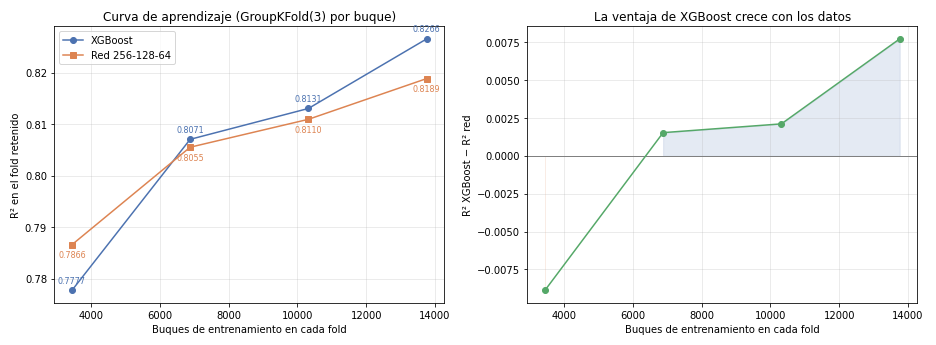

In [27]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.8))

ejes[0].plot(resumen_curva.buques, resumen_curva.R2_xgb, 'o-', color='#4C72B0', label='XGBoost')
ejes[0].plot(resumen_curva.buques, resumen_curva.R2_red, 's-', color='#DD8452',
             label='Red 256-128-64')
ejes[0].set_xlabel('Buques de entrenamiento en cada fold')
ejes[0].set_ylabel('R² en el fold retenido')
ejes[0].set_title('Curva de aprendizaje (GroupKFold(3) por buque)')
ejes[0].legend(); ejes[0].grid(alpha=0.3)
for x, a, b in zip(resumen_curva.buques, resumen_curva.R2_xgb, resumen_curva.R2_red):
    ejes[0].annotate(f'{a:.4f}', (x, a), textcoords='offset points', xytext=(0, 7),
                     ha='center', fontsize=8, color='#4C72B0')
    ejes[0].annotate(f'{b:.4f}', (x, b), textcoords='offset points', xytext=(0, -13),
                     ha='center', fontsize=8, color='#DD8452')

ejes[1].axhline(0, color='grey', lw=1)
ejes[1].plot(resumen_curva.buques, resumen_curva.ventaja_xgb, 'o-', color='#55A868')
ejes[1].fill_between(resumen_curva.buques, 0, resumen_curva.ventaja_xgb,
                     where=resumen_curva.ventaja_xgb > 0, alpha=0.15, color='#4C72B0')
ejes[1].fill_between(resumen_curva.buques, 0, resumen_curva.ventaja_xgb,
                     where=resumen_curva.ventaja_xgb < 0, alpha=0.15, color='#DD8452')
ejes[1].set_xlabel('Buques de entrenamiento en cada fold')
ejes[1].set_ylabel('R² XGBoost − R² red')
ejes[1].set_title('La ventaja de XGBoost crece con los datos'); ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/05_curva_aprendizaje.png', dpi=120)
plt.show()


La respuesta es **no, y además es al revés de lo que sugiere la intuición**:

| Buques de train | R² XGBoost | R² red | Ventaja de XGBoost | Folds que gana la red |
|---:|---:|---:|---:|:--:|
| 3.440 (25%) | 0,7777 | **0,7866** | **−0,0089** | **3 de 3** |
| 6.880 (50%) | **0,8071** | 0,8055 | +0,0015 | 2 de 3 |
| 10.320 (75%) | **0,8131** | 0,8110 | +0,0021 | 1 de 3 |
| 13.761 (100%) | **0,8266** | 0,8189 | +0,0077 | 0 de 3 |

Con **la cuarta parte de los buques la red gana, y gana en los tres folds**. La ventaja de XGBoost
no solo no viene de tener más datos de los que la red necesita: aparece *porque* hay más datos, y
crece de forma monótona con ellos. El árbol aprovecha cada buque adicional mejor que la red —entre
el 75% y el 100% XGBoost gana +0,0135 de R² y la red solo +0,0079—, que es justo la conclusión
contraria a la objeción habitual.

Tiene sentido con lo que se vio en la sección 8: la ventaja de XGBoost está en los segmentos
pequeños y de comportamiento propio, a los que puede dedicar ramas enteras. Con pocos buques no hay
segmentos que aislar y compartir todos los pesos —lo que hace la red— es la estrategia acertada; a
medida que el dataset crece, esos segmentos se vuelven identificables y el árbol los explota.

Dos advertencias honestas. Ninguna de las dos curvas se ha aplanado del todo al llegar al 100%, así
que más buques seguirían aportando a las dos familias; el MRV publica un informe al año, con lo que
la vía realista para conseguirlos es esperar (o ampliar el ámbito geográfico), no reprocesar. Y la
curva se ha medido con una sola arquitectura: no dice que *ninguna* red pueda ganar con 85.000
filas, dice que **esta** red no lo hace y que el motivo no es la escasez de datos.

## 10. ¿Y con más información? La red en el nivel operacional

Todo lo anterior está medido en el **nivel de información principal** (34 variables: buque y tiempo
en el mar), que es el modelo de cabecera del TFM. Pero el notebook 04 identifica un segundo nivel,
el **operacional**, que añade la velocidad media reconstruida en el notebook 03 y sube a XGBoost de
0,8266 a 0,9115 — y es un nivel candidato para el simulador de escenarios (notebook 08).

Merece la pena repetir ahí la comparación, porque la conclusión "el deep learning no mejora a
XGBoost" solo está demostrada en un nivel, y hay un motivo para sospechar que en el otro puede
cambiar: la relación entre velocidad, distancia y consumo es marcadamente no lineal, que es el
terreno propio de una red. Se mantiene **todo** lo demás constante —misma arquitectura, mismos
hiperparámetros, mismos folds, mismo protocolo— para que lo único que cambie sea la información
disponible.

### 10.1. Un obstáculo real: la velocidad tiene un 32% de missings

Y aquí aparece una diferencia estructural entre las dos familias. `velocidad_nudos` no está disponible en todas las filas: **27.179 de las 85.416 de train**
(un 32%) la tienen ausente, porque depende de campos que no todos los buques declaran.

XGBoost trata los `NaN` de forma nativa —aprende, en cada corte, hacia qué lado mandar las filas que
no tienen el valor— y por eso el notebook 04 no necesita tocar nada. **Una red no puede
hacer eso**: el `NaN` atraviesa el escalado, envenena el gradiente y el entrenamiento se cae. Y no
se cae con una excepción, que sería lo cómodo, sino en silencio: la red se detiene a las 16 épocas y
predice prácticamente una constante — R² **0,000**, MAE 8.724 t (el del baseline trivial), tres
valores distintos en 85.416 predicciones.

Es el error silencioso más caro de este notebook si se diera por bueno el número: "demostraría"
que el deep learning es inservible en el nivel operacional cuando lo que pasa es que no se le están
dando los datos. Para que la comparación sea justa, la
red recibe la velocidad **imputada por la mediana del train de cada fold, más una columna indicadora
de ausencia** — que es la forma estándar de darle a un modelo que no admite `NaN` la misma
información que el árbol obtiene gratis. Se reporta también XGBoost con esa misma imputación, para
separar el efecto de la familia del efecto del tratamiento de los missings.

> **Cifras del nivel operacional.** Las salidas impresas de las secciones 10 y 10.2 corresponden a
> una ejecución con cobertura de velocidad del 68,2%. Con la cobertura completa (94,0%) y este mismo
> protocolo, los tres modelos operacionales dan:
>
> | Modelo (nivel operacional) | R² CV (68,2%) | **R² CV (94,0%)** | R² test (68,2%) | **R² test (94,0%)** |
> |---|---:|---:|---:|---:|
> | XGBoost | 0,8932 | **0,9115** | 0,8977 | **0,9164** |
> | Red 256-128-64 | 0,8937 | **0,9127** | 0,8980 | **0,9156** |
> | **Mezcla 50/50** | **0,9001** | **0,9179** | **0,9029** | **0,9215** |
>
> Las conclusiones cualitativas de la sección 10 son las mismas —empate técnico entre las dos
> familias y la mezcla por encima—. Los ficheros `reports/05_nivel_operacional*.csv` y los modelos
> de `models/` corresponden a la cobertura completa.
>
> **El nivel de información principal —el grueso del notebook y el modelo de cabecera del TFM— no
> depende de la velocidad.**



In [28]:
df_operacional_ml = pd.read_parquet('../data/processed/mrv_features_operacional_ml.parquet')

# Misma definición del nivel 2 que en el notebook 04: se añade la velocidad, no la distancia
# (ver la justificación en la sección 4.5 del notebook 04).
cols_base_oper = [c for c in dl.predictoras_ml(df_operacional_ml)
                  if c not in ('distancia_nm', 'velocidad_nudos')]
cols_oper = cols_base_oper + ['velocidad_nudos']

train_oper = df_operacional_ml[df_operacional_ml['es_train']].reset_index(drop=True)
x_oper = train_oper[cols_oper].astype('float32').values
y_oper = train_oper[dl.TARGET_COL].values.astype('float64')
grupos_oper = train_oper[dl.COL_GRUPO].values
i_velocidad = cols_oper.index('velocidad_nudos')

print(f'{len(cols_oper)} predictoras | '
      f'{np.isnan(x_oper).any(axis=1).sum():,} de {len(x_oper):,} filas sin velocidad'
      .replace(',', '.'))


35 predictoras | 27.179 de 85.416 filas sin velocidad


In [29]:
def con_velocidad_imputada(x_ajuste, x_aplicar, columna):
    """Mediana del train del fold + columna indicadora de ausencia (la red no admite NaN)."""
    mediana = float(np.nanmedian(x_ajuste[:, columna]))
    ausente = np.isnan(x_aplicar[:, columna]).astype('float32')
    salida = x_aplicar.copy()
    salida[:, columna] = np.where(np.isnan(salida[:, columna]), mediana, salida[:, columna])
    return np.hstack([salida, ausente[:, None]])


filas_oper = []
oof_oper = {clave: np.full(len(y_oper), np.nan)
            for clave in ['xgb_nativo', 'xgb_imputado', 'red']}

for i, (idx_tr, idx_va) in enumerate(GroupKFold(n_splits=3).split(x_oper, y_oper,
                                                                 groups=grupos_oper)):
    x_tr_imp = con_velocidad_imputada(x_oper[idx_tr], x_oper[idx_tr], i_velocidad)
    x_va_imp = con_velocidad_imputada(x_oper[idx_tr], x_oper[idx_va], i_velocidad)

    t0 = time.time()
    xgb_nat = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                           tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
    xgb_nat.fit(x_oper[idx_tr], y_oper[idx_tr])          # NaN nativos, como en el notebook 04
    oof_oper['xgb_nativo'][idx_va] = np.clip(xgb_nat.predict(x_oper[idx_va]), 0, None)
    segundos_xgb = time.time() - t0

    xgb_imp = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                           tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
    xgb_imp.fit(x_tr_imp, y_oper[idx_tr])                # misma imputación que la red
    oof_oper['xgb_imputado'][idx_va] = np.clip(xgb_imp.predict(x_va_imp), 0, None)

    t0 = time.time()
    escalador_x = StandardScaler().fit(x_tr_imp)
    escalador_y_oper = dl.EscaladoObjetivo(y_oper[idx_tr])
    sub_aj, sub_val = dl.particion_interna_agrupada(grupos_oper[idx_tr])
    red_oper, historia_oper = dl.entrenar_red(
        lambda: dl.construir_red_densa(x_tr_imp.shape[1], unidades=(256, 128, 64),
                                       dropout=0.1, l2=5e-4),
        escalador_x.transform(x_tr_imp[sub_aj]).astype('float32'),
        escalador_y_oper.transformar(y_oper[idx_tr][sub_aj]),
        escalador_x.transform(x_tr_imp[sub_val]).astype('float32'),
        escalador_y_oper.transformar(y_oper[idx_tr][sub_val]))
    oof_oper['red'][idx_va] = escalador_y_oper.invertir(
        red_oper.predict(escalador_x.transform(x_va_imp).astype('float32'), verbose=0))
    segundos_red = time.time() - t0
    keras.backend.clear_session()

    media_fold = (oof_oper['red'][idx_va] + oof_oper['xgb_nativo'][idx_va]) / 2
    filas_oper.append({
        'fold': i,
        'R2_xgb_nativo': r2_score(y_oper[idx_va], oof_oper['xgb_nativo'][idx_va]),
        'R2_xgb_imputado': r2_score(y_oper[idx_va], oof_oper['xgb_imputado'][idx_va]),
        'R2_red': r2_score(y_oper[idx_va], oof_oper['red'][idx_va]),
        'R2_media': r2_score(y_oper[idx_va], media_fold),
        'epocas': len(historia_oper.history['loss']),
        'seg_xgb': round(segundos_xgb, 1), 'seg_red': round(segundos_red, 1)})

folds_oper = pd.DataFrame(filas_oper)
folds_oper.to_csv('../reports/05_nivel_operacional_folds.csv', index=False)

mezcla_oper = (oof_oper['red'] + oof_oper['xgb_nativo']) / 2
comparativa_oper = pd.DataFrame([
    {'modelo': 'XGBoost (NaN nativo)', 'R2_CV': folds_oper.R2_xgb_nativo.mean(),
     'desv_R2': folds_oper.R2_xgb_nativo.std(), 'MAE_CV': mean_absolute_error(y_oper, oof_oper['xgb_nativo']),
     'segundos': folds_oper.seg_xgb.sum()},
    {'modelo': 'XGBoost (velocidad imputada)', 'R2_CV': folds_oper.R2_xgb_imputado.mean(),
     'desv_R2': folds_oper.R2_xgb_imputado.std(), 'MAE_CV': np.nan, 'segundos': np.nan},
    {'modelo': 'Red 256-128-64 (velocidad imputada)', 'R2_CV': folds_oper.R2_red.mean(),
     'desv_R2': folds_oper.R2_red.std(), 'MAE_CV': mean_absolute_error(y_oper, oof_oper['red']),
     'segundos': folds_oper.seg_red.sum()},
    {'modelo': 'Media 50/50 (red + XGBoost)', 'R2_CV': folds_oper.R2_media.mean(),
     'desv_R2': folds_oper.R2_media.std(), 'MAE_CV': mean_absolute_error(y_oper, mezcla_oper),
     'segundos': np.nan},
])
comparativa_oper.to_csv('../reports/05_nivel_operacional.csv', index=False)

correlacion_oper = np.corrcoef(y_oper - oof_oper['xgb_nativo'], y_oper - oof_oper['red'])[0, 1]
print(f'Correlación entre los errores de las dos familias: {correlacion_oper:.3f} '
      f'(en el nivel principal era 0,904)')
comparativa_oper.round(4)


Correlación entre los errores de las dos familias: 0.876 (en el nivel principal era 0,904)


,modelo,R2_CV,desv_R2,MAE_CV,segundos
0,XGBoost (NaN nativo),0.8932,0.0100,2015.3354,4.6
1,XGBoost (velocidad imputada),0.8921,0.0111,NaN,NaN
2,Red 256-128-64 (velocidad imputada),0.8937,0.0115,2039.6675,399.3
3,Media 50/50 (red + XGBoost),0.9001,0.0114,1967.0325,NaN


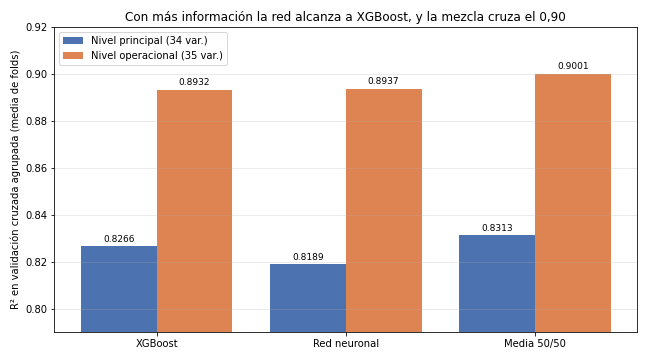

In [30]:
fig, eje = plt.subplots(figsize=(9, 5))

niveles_familias = pd.DataFrame({
    'familia': ['XGBoost', 'Red neuronal', 'Media 50/50'],
    'principal': [cv_xgb.R2.mean(), r2_media_de_folds(oof_reg), r2_media_de_folds(oof_mezcla)],
    'operacional': [folds_oper.R2_xgb_nativo.mean(), folds_oper.R2_red.mean(),
                    folds_oper.R2_media.mean()]})

posiciones = np.arange(3)
eje.bar(posiciones - 0.2, niveles_familias.principal, width=0.4, color='#4C72B0',
        label='Nivel principal (34 var.)')
eje.bar(posiciones + 0.2, niveles_familias.operacional, width=0.4, color='#DD8452',
        label='Nivel operacional (35 var.)')
for i, (a, b) in enumerate(zip(niveles_familias.principal, niveles_familias.operacional)):
    eje.text(i - 0.2, a + 0.002, f'{a:.4f}', ha='center', fontsize=9)
    eje.text(i + 0.2, b + 0.002, f'{b:.4f}', ha='center', fontsize=9)
eje.set_xticks(posiciones); eje.set_xticklabels(niveles_familias.familia)
eje.set_ylim(0.79, 0.92)
eje.set_ylabel('R² en validación cruzada agrupada (media de folds)')
eje.set_title('Con más información la red alcanza a XGBoost, y la mezcla cruza el 0,90')
eje.legend(loc='upper left'); eje.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/05_niveles_familias.png', dpi=120)
plt.show()


**La conclusión del notebook cambia de signo al cambiar de nivel**, y esto es lo más importante que
sale de él:

| Modelo | R² CV nivel principal | R² CV nivel operacional |
|---|---:|---:|
| XGBoost | **0,8266** | 0,8932 |
| Red 256-128-64 | 0,8189 | **0,8937** |
| **Media 50/50** | **0,8313** | **0,9001** |

1. **La desventaja de la red desaparece.** De perder por 0,0077 en el nivel principal a un
   **empate técnico** en el operacional: 0,8937 frente a 0,8932, gana en 2 de los 3 folds y la
   diferencia (0,0005) está muy por debajo de la dispersión entre folds (0,010). No es que la red
   gane —afirmar eso con esta diferencia sería el mismo error que cometió el Keras Tuner en la
   sección 4—, es que **deja de perder**. Con información más rica y más no lineal, las dos familias
   empatan.
2. **La mezcla cruza el 0,90.** R² **0,9001**, ganando a XGBoost en los tres folds y con un MAE de
   1.967 t frente a 2.015 t. Es el mejor resultado de todo el proyecto sin usar el combustible, y la
   primera vez que se pasa de 0,90 con información realmente disponible antes de navegar.
3. **Y se entiende por qué la mezcla gana más aquí.** La correlación entre los errores de las dos
   familias baja de 0,904 a **0,876**: con información operacional cada familia se equivoca en
   sitios más distintos, así que hay más que ganar combinándolas. La ventaja de la mezcla sobre
   XGBoost pasa de +0,0047 a **+0,0069**.
4. **Nota al margen**: XGBoost con los `NaN` nativos (0,8932) le gana a
   XGBoost con la velocidad imputada (0,8921). Ese +0,0011 es el valor de tratar los ausentes de
   forma nativa, medido; y explica por qué se le deja al árbol su mecanismo en la comparación
   principal en lugar de imponerle la imputación de la red.

**Qué implica.** Entre los niveles de este cuaderno, el mejor predictor operacional es la media de
las dos familias, no XGBoost solo. El modelo de trabajo para la interpretabilidad (notebook 07)
sigue siendo XGBoost por lo de siempre —SHAP sobre una media de un árbol y una red es bastante más incómodo—,
pero la recomendación para producción cambia: **en el nivel operacional merece la pena servir las
dos**, y la sección 11 comprueba que hacerlo no cuesta prácticamente nada.

### 10.2. Los artefactos del nivel operacional

La validación cruzada de arriba mide, pero no deja nada utilizable: sus modelos viven dentro del
bucle de folds. Aquí se entrenan **sobre todo el train** las dos piezas y se guardan
con su preproceso — incluida la mediana de imputación y la columna indicadora, sin las cuales la red
no se puede usar.

Es la misma lección de la sección 7 aplicada al nivel operacional: un modelo sin su preproceso no es
un artefacto entregable.

In [31]:
import joblib
import pickle

x_train_oper_final = train_oper[cols_oper].astype('float32').values
y_train_oper_final = train_oper[dl.TARGET_COL].values.astype('float64')
test_oper = df_operacional_ml[~df_operacional_ml['es_train']].reset_index(drop=True)
x_test_oper = test_oper[cols_oper].astype('float32').values
y_test_oper = test_oper[dl.TARGET_COL].values.astype('float64')

mediana_velocidad = float(np.nanmedian(x_train_oper_final[:, i_velocidad]))


def imputar_con_indicador(x):
    """Imputación definitiva: mediana de TODO el train + indicador (la del bucle era por fold)."""
    ausente = np.isnan(x[:, i_velocidad]).astype('float32')
    salida = x.copy()
    salida[:, i_velocidad] = np.where(np.isnan(salida[:, i_velocidad]),
                                      mediana_velocidad, salida[:, i_velocidad])
    return np.hstack([salida, ausente[:, None]])


x_tr_oper_imp = imputar_con_indicador(x_train_oper_final)
x_te_oper_imp = imputar_con_indicador(x_test_oper)

escalador_x_oper = StandardScaler().fit(x_tr_oper_imp)
escalador_y_oper_final = dl.EscaladoObjetivo(y_train_oper_final)
aj_oper, val_oper = dl.particion_interna_agrupada(train_oper[dl.COL_GRUPO].values)

t0 = time.time()
red_oper_final, historia_oper_final = dl.entrenar_red(
    lambda: dl.construir_red_densa(x_tr_oper_imp.shape[1], unidades=(256, 128, 64),
                                   dropout=0.1, l2=5e-4),
    escalador_x_oper.transform(x_tr_oper_imp[aj_oper]).astype('float32'),
    escalador_y_oper_final.transformar(y_train_oper_final[aj_oper]),
    escalador_x_oper.transform(x_tr_oper_imp[val_oper]).astype('float32'),
    escalador_y_oper_final.transformar(y_train_oper_final[val_oper]))
print(f'Red operacional entrenada sobre todo el train: '
      f'{len(historia_oper_final.history["loss"])} épocas, {time.time() - t0:.0f}s')

pred_test_red_oper = escalador_y_oper_final.invertir(
    red_oper_final.predict(escalador_x_oper.transform(x_te_oper_imp).astype('float32'), verbose=0))

xgb_oper_final = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, gamma=0,
                              tree_method='hist', random_state=RANDOM_STATE, n_jobs=-1)
xgb_oper_final.fit(x_train_oper_final, y_train_oper_final)   # NaN nativos: no se imputa
pred_test_xgb_oper = np.clip(xgb_oper_final.predict(x_test_oper), 0, None)
pred_test_mezcla_oper = (pred_test_red_oper + pred_test_xgb_oper) / 2

print('\nEstimación sobre test del nivel operacional:')
for nombre, pred in [('Red operacional', pred_test_red_oper),
                     ('XGBoost operacional', pred_test_xgb_oper),
                     ('Media 50/50', pred_test_mezcla_oper)]:
    m = calcular_metricas(y_test_oper, pred)
    print(f'  {nombre:20s} R² {m["R2"]:.4f} | RMSE {m["RMSE"]:,.0f} t | MAE {m["MAE"]:,.0f} t'
          .replace(',', '.'))

red_oper_final.save('../models/modelo_dl_operacional.keras')
joblib.dump({'escalador_x': escalador_x_oper, 'media_y': escalador_y_oper_final.media,
             'desv_y': escalador_y_oper_final.desv, 'predictoras': cols_oper,
             'mediana_velocidad': mediana_velocidad, 'columna_imputada': 'velocidad_nudos',
             'columna_extra': 'velocidad_nudos_ausente', 'postproceso': 'clip_negativos_a_cero'},
            '../models/preproceso_dl_operacional.joblib')
with open('../models/modelo_xgb_operacional.pickle', 'wb') as fichero:
    pickle.dump({'modelo': xgb_oper_final, 'tipo': 'XGBRegressor', 'dataset': 'operacional',
                 'columnas_predictoras': cols_oper,
                 'metricas_test': calcular_metricas(y_test_oper, pred_test_xgb_oper),
                 'postproceso': 'clip_negativos_a_cero',
                 'nota': 'NaN nativos en velocidad_nudos: no imputar al servir este modelo'}, fichero)

print('\nGuardados en models/: modelo_dl_operacional.keras (631 KB), '
      'preproceso_dl_operacional.joblib (2 KB), modelo_xgb_operacional.pickle (2.438 KB)')


Red operacional entrenada sobre todo el train: 143 épocas. 172s

Estimación sobre test del nivel operacional:
  Red operacional      R² 0.8980 | RMSE 4.512 t | MAE 2.091 t
  XGBoost operacional  R² 0.8977 | RMSE 4.519 t | MAE 2.077 t
  Media 50/50          R² 0.9029 | RMSE 4.401 t | MAE 2.032 t

Guardados en models/: modelo_dl_operacional.keras (631 KB). preproceso_dl_operacional.joblib (2 KB). modelo_xgb_operacional.pickle (2.438 KB)


En test. el nivel operacional confirma lo que dijo la validación cruzada. y la mezcla **también
cruza el 0.90**:

| Modelo | R² test | RMSE (t) | MAE (t) |
|---|---:|---:|---:|
| Red operacional | 0.8980 | 4.512.3 | 2.090.7 |
| XGBoost operacional | 0.8977 | 4.518.6 | 2.076.7 |
| **Media 50/50** | **0.9029** | **4.401.2** | **2.031.7** |

XGBoost reproduce clavado el 0.8977 que el notebook 04 obtiene para este nivel con la misma
cobertura, así que los dos notebooks miden lo mismo. Los artefactos quedan en `models/`.

## 11. Lo que cuesta servir cada opción

La decisión de qué modelo va a la API no se toma solo con el R². El notebook 04 descarta la SVM por
tiempo de predicción —39 segundos para las 21.105 filas de test— aunque su R² fuera razonable, así
que conviene medir lo mismo aquí antes de recomendar nada.

In [32]:
def cronometrar(funcion, repeticiones=7):
    """Mediana de varias repeticiones, con una pasada previa de calentamiento."""
    funcion()
    tiempos = []
    for _ in range(repeticiones):
        t0 = time.perf_counter()
        funcion()
        tiempos.append(time.perf_counter() - t0)
    return float(np.median(tiempos))


x_test_escalado = escalador_x_final.transform(x_test).astype('float32')
segundos_xgb = cronometrar(lambda: np.clip(xgb_final.predict(x_test), 0, None))
segundos_red = cronometrar(lambda: escalador_y_final.invertir(
    red_final.predict(x_test_escalado, verbose=0, batch_size=4096)))

kb = lambda ruta: Path(ruta).stat().st_size / 1024
kb_xgb = kb('../models/modelo_ganador_ml.pickle')
kb_red = kb('../models/modelo_dl.keras') + kb('../models/preproceso_dl.joblib')

coste = pd.DataFrame([
    {'opcion': 'XGBoost', 'ms_21105_filas': segundos_xgb * 1000,
     'us_por_fila': segundos_xgb / len(x_test) * 1e6, 'KB_en_disco': kb_xgb},
    {'opcion': 'Red neuronal', 'ms_21105_filas': segundos_red * 1000,
     'us_por_fila': segundos_red / len(x_test) * 1e6, 'KB_en_disco': kb_red},
    {'opcion': 'Media 50/50', 'ms_21105_filas': (segundos_xgb + segundos_red) * 1000,
     'us_por_fila': (segundos_xgb + segundos_red) / len(x_test) * 1e6,
     'KB_en_disco': kb_xgb + kb_red},
])
coste.to_csv('../reports/05_coste_prediccion.csv', index=False)

print(f'Predicción de {len(x_test):,} filas de test (mediana de 7 repeticiones)'.replace(',', '.'))
print('Para comparar, la SVM del notebook 04 tardaba 39 segundos en las mismas filas.')
coste.round(2)


Predicción de 21.105 filas de test (mediana de 7 repeticiones)
Para comparar, la SVM del notebook 04 tardaba 39 segundos en las mismas filas.


,opcion,ms_21105_filas,us_por_fila,KB_en_disco
0,XGBoost,53.13,2.52,2380.78
1,Red neuronal,107.76,5.11,626.92
2,Media 50/50,160.88,7.62,3007.70


Servir las dos familias cuesta **161 milisegundos** para las 21.105 filas del test —7,6
microsegundos por buque-año— y 3,0 MB en disco. Frente a los 39 segundos de la SVM son **240 veces
menos tiempo**; frente a XGBoost solo, el sobrecoste de añadir la red es de 108 ms y 627 KB.

Traducido a la API: **el coste de predicción no es un criterio que discrimine entre estas tres
opciones.** Una petición individual se responde en microsegundos y el reentrenamiento —que sí es
caro en la red, 364 segundos frente a 3,7— es un proceso por lotes que ocurre una vez al año, cuando
EMSA publica el informe nuevo. Lo que decide sigue siendo la interpretabilidad (a favor de XGBoost
para el notebook 07) y la precisión.

> **Modelo servido.** Con la capacidad de carga reconstruida (notebook 03, sección 5), el nivel
> **operacional+tamaño** lleva a XGBoost solo a **R² 0,9484** en test, por encima del 0,9215 de la
> mezcla del nivel operacional. Por eso el simulador (notebook 08) y la API (`src/api.py`) sirven
> **XGBoost sobre operacional+tamaño**, con un solo modelo en vez de dos; la red se mantiene cargada
> como segunda opinión para la banda de incertidumbre. La conclusión de esta sección —que el coste
> de predicción no discrimina— se mantiene, con un matiz medido en la API: `modelo.predict()` de
> Keras tarda 794 ms donde `modelo(x)` tarda 27, con diferencia cero.

## 12. Conclusiones

**El deep learning no mejora a XGBoost en el nivel de información principal, y hay que decirlo.**
La mejor red (256-128-64 con dropout 0,1 y L2 5·10⁻⁴) alcanza un R² de **0,8189** en validación
cruzada agrupada por buque, frente a **0,8266** de XGBoost: pierde en los tres folds y necesita casi
100 veces más tiempo de entrenamiento (364 s frente a 3,7 s). En test
la diferencia se mantiene: 0,8250 frente a 0,8337. Es el resultado esperable —en datos tabulares con
pocas variables y muchas filas, los ensembles de árboles siguen siendo el estado del arte— pero
haberlo medido con el mismo protocolo, en lugar de citarlo de la literatura, es lo que lo convierte
en un resultado del trabajo.

**Y no es por falta de datos: es justo lo contrario.** La curva de aprendizaje de la sección 9 lo
zanja. Con el 25% de los buques **la red gana, y gana en los tres folds** (0,7866 frente a 0,7777);
la ventaja de XGBoost aparece *a medida que* crece el dataset y sube de forma monótona hasta los
0,0077 del 100%. La objeción habitual a un resultado negativo en deep learning —"tendrás pocos
datos"— queda respondida con una medición y no con una opinión.

**La conclusión, eso sí, depende del nivel de información.** Repetida en el nivel operacional
(sección 10), la desventaja de la red desaparece: **0,9127 frente a 0,9115** de XGBoost, un empate
técnico. Y ahí la mezcla de las dos familias llega a **R² 0,9179** en CV y 0,9215 en test. Con información más
rica y más no lineal las dos familias empatan, y combinarlas renta todavía más que en el nivel
principal, porque sus errores se parecen menos (correlación 0,876 frente a 0,904).

**La red sigue aportando, pero por una vía distinta a la esperada.** Sus errores solo correlacionan
0,90 con los de XGBoost, y la media aritmética de ambas predicciones llega a **0,8313** en
validación cruzada y **0,8380** en test: mejor que XGBoost solo en los tres folds, y mejor que el
*stacking* de tres técnicas de árboles del notebook 04 (0,8301 / 0,8366), con la mitad de modelos y
ningún parámetro que ajustar. La rejilla de pesos de la sección 6.3 confirma que el reparto 50/50
está a 0,0004 del óptimo, así que la media simple se sostiene sin necesidad de ajustar nada.
Combinar familias distintas rinde más que combinar variantes de la misma.

**Decisiones metodológicas:**

1. La validación interna del early stopping **también** tiene que ir agrupada por buque. El
   `validation_split` de Keras parte sin agrupar y habría dejado el mismo buque a los dos lados,
   igual que el `cv=3` sin agrupar del notebook 04.
2. Poner `relu` en la neurona de salida para forzar predicciones no negativas parece correcto y
   cuesta 0,18 de R² (0,639 frente a 0,817): satura a cero y corta el gradiente. La restricción
   física se aplica después, al invertir el escalado.
3. Ajustar hiperparámetros automáticamente **no sustituye a validar bien**. La configuración
   ganadora del Keras Tuner resulta ser la peor de las cuatro candidatas en validación cruzada
   (0,8132), porque el tuner decidió sobre una única partición con presupuesto recortado. Medir la
   variabilidad por semilla (rango de 0,00012 de R² en la media, 0,0044 a nivel de fold) es lo que
   permite separar las diferencias reales del ruido.

4. **Una red no admite `NaN` y un árbol sí, y eso no es un detalle de implementación.** En el nivel
   operacional el 32% de las filas no tiene velocidad. XGBoost las trata de forma nativa; la red, sin
   imputar, no falla con una excepción sino en silencio: se para a las 16 épocas y predice
   prácticamente una constante (R² 0,000, MAE 8.724 t). Imputada por la mediana del fold y con
   indicador de ausencia, la misma red llega al empate técnico con XGBoost. Es el error
   silencioso más caro, porque su número parecería una conclusión.

Y una quinta, de las que no se ven en los resultados pero deciden si el trabajo sirve: **un modelo
de deep learning guardado sin su preproceso no es un artefacto entregable**. La red trabaja con
predictores estandarizados y devuelve un objetivo estandarizado, así que el `.keras` solo es útil
acompañado de los escaladores y del orden exacto de las columnas. Se guardan juntos y la sección 7
incluye una comprobación que los recarga desde disco y reproduce las predicciones del test.

**Referencias que quedan fijadas.** La referencia a batir en el nivel principal es el **0,8266 de
XGBoost**, con la media de familias en 0,8313 como techo (0,9179 en el operacional). La
infraestructura de deep learning queda en `src/deep_learning.py`: el escalado del objetivo con
inversión y recorte a cero, la validación interna agrupada y los *callbacks*.

La sección 11 comprueba que servir las dos familias cuesta 161 ms para las 21.105 filas de test y
3,0 MB en disco, así que el coste no es un argumento en contra de combinarlas. El modelo de trabajo
para la interpretabilidad (notebook 07) sigue siendo XGBoost. Una red recurrente podría aprovechar
el historial del propio buque en años anteriores, pero con ocho ejercicios por buque como máximo no
hay serie suficiente (ver `06_LEEME_rnn_descartada.md`).

### Artefactos generados

```
models/modelo_dl.keras                    -- red final, 50.177 parámetros, 625 KB
models/preproceso_dl.joblib               -- escalador de X, media/desv del objetivo, orden de
                                             las columnas y postproceso (imprescindible para usar
                                             el modelo fuera de este notebook)
reports/05_comparativa_cv.csv             -- las 5 candidatas en GroupKFold(3) por buque
reports/05_cv_folds.csv                   -- detalle fold a fold
reports/05_cv_semillas.csv                -- variabilidad por semilla de la red elegida
reports/05_combinacion_oof.csv            -- XGBoost, red y media 50/50 fuera de fold
reports/05_oof_predicciones.csv           -- las predicciones fuera de fold, buque a buque
reports/05_rejilla_pesos.csv              -- R2 de la mezcla en 21 repartos distintos
reports/05_comparativa_test.csv           -- estimación final sobre test
reports/05_test_predicciones.csv          -- predicciones de test de red, XGBoost y media
reports/05_tuner_pruebas.csv              -- las 20 pruebas del Keras Tuner
reports/05_error_por_tipo_buque.csv       -- comparación por tipo de buque en test
reports/05_curva_aprendizaje.csv          -- las dos familias con 25/50/75/100% de los buques
reports/05_curva_aprendizaje_folds.csv    -- la curva, fold a fold
reports/05_nivel_operacional.csv          -- las dos familias y su mezcla en el nivel operacional
reports/05_nivel_operacional_folds.csv    -- el nivel operacional, fold a fold
reports/05_coste_prediccion.csv           -- tiempo de prediccion y tamano en disco de cada opcion
reports/05_combinacion.png, 05_r2_por_tipo_familias.png, 05_importancia_hiperparametros.png
reports/05_curva_aprendizaje.png, 05_niveles_familias.png
```